
# Frequency detection by Fourier Transform



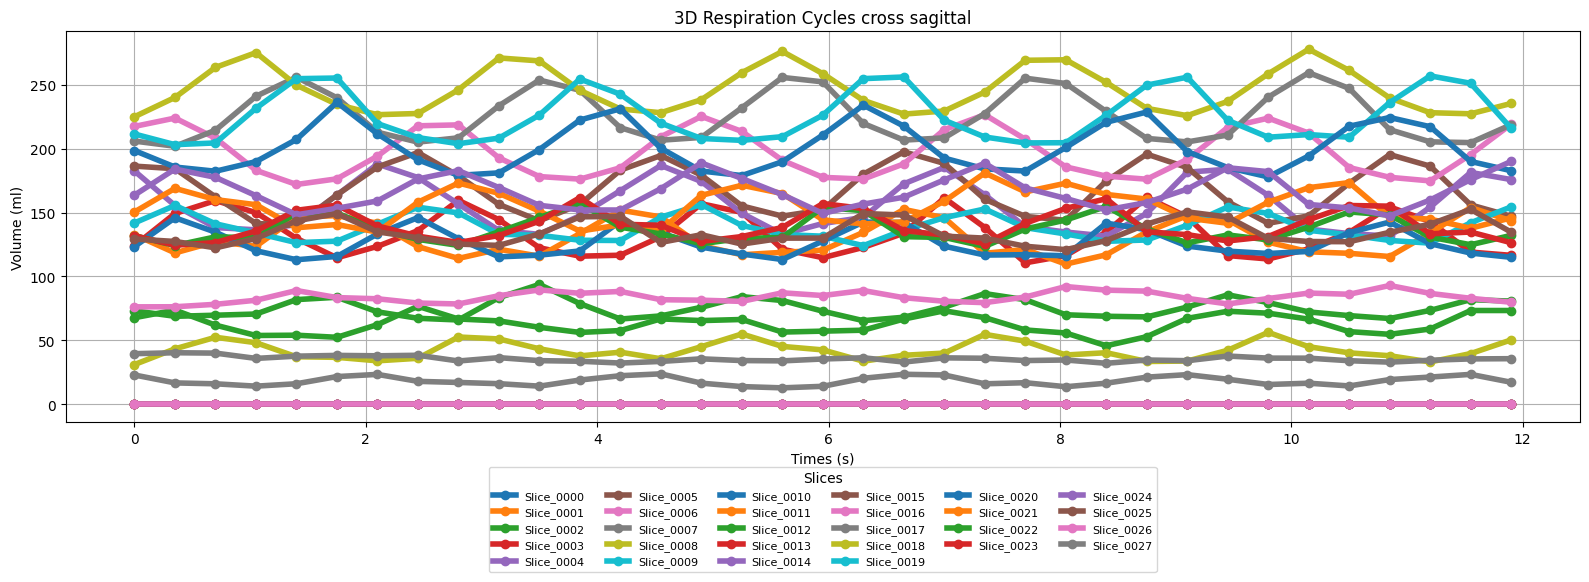

28


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Define the root path containing the folders
root_path = r'F:\Alex-programing\programing\4D_Dynamic_Volume_estimation\Sample_Mask'

# List specific folder names (Slice_0000 to Slice_00028)
folder_names = [f"Slice_{i:04d}" for i in range(0, 28)]

# Initialize dictionaries to store results
results = {}
sum_white_points_per_frame = {}
f=[]

# Process each folder
for folder_name in folder_names:
    folder_path = os.path.join(root_path, folder_name)
    
    # Check if the folder exists
    if not os.path.exists(folder_path):
        print(f"Warning: Folder {folder_path} does not exist.")
        continue
    
    # List all JPG files in the folder
    image_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.jpg')])
    
    if not image_files:
        print(f"Warning: No image files found in {folder_path}.")
        continue  # Skip empty folders
    
    # Initialize storage for the current folder
    frame_indices = []
    white_points = []
    
    # Process each image in the current folder
    for i, file_name in enumerate(image_files):
        file_path = os.path.join(folder_path, file_name)
        
        # Load image in grayscale
        frame = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
        
        if frame is None:
            print(f"Error: Could not load image {file_path}")
            continue
        
        # Count white pixels (value == 255)
        white_count = ((np.sum(frame == 255))* 1.973 * 8)/1000
        
        # Store results
        frame_indices.append(i)
        white_points.append(white_count)
        
        # Update the sum of white points for this frame index across all folders
        if i not in sum_white_points_per_frame:
            sum_white_points_per_frame[i] = 0
        sum_white_points_per_frame[i] += white_count
    f.append(signal.resample(white_points, 35))
    # Save results for this folder
    results[folder_name] = (frame_indices, white_points)

fig, axes = plt.subplots(1, 1, figsize=(16, 6))

# --- Left Plot: 3D cycles ---


for folder_name, (frame_indices, white_points) in results.items():
    frame_time = np.array(frame_indices)*350/1000
    plt.plot(frame_time, white_points, marker='o', label=folder_name, linewidth=4.0)

plt.title("3D Respiration Cycles cross sagittal")
plt.xlabel("Times (s)")
plt.ylabel("Volume (ml)")
plt.grid(True)

# Put legend above the plot
plt.legend(
    title="Slices",
    bbox_to_anchor=(0.5, -0.1),  # center top
    loc='upper center',
    ncol=6,
    fontsize=8,
    title_fontsize=10
) 
# # Plot the sum of white points across all folders
# total_frame_indices = sorted(sum_white_points_per_frame.keys())
# total_white_points = [sum_white_points_per_frame[i] for i in total_frame_indices]


# time = np.array(total_frame_indices)  # Assuming each index is 1 frame

# # --- Right Plot: 4D cycle ---
# axes[1].plot(time, total_white_points, marker='o', linestyle='-', color='b')
# axes[1].set_title("4D Respiration Cycle")
# axes[1].set_xlabel("Times")
# axes[1].set_ylabel("Volume")
# axes[1].grid(True)

# Adjust layout and save
plt.tight_layout()
plt.savefig("3D_4D_combined.pdf", format="pdf", bbox_inches="tight")
plt.show()
print(len(f))



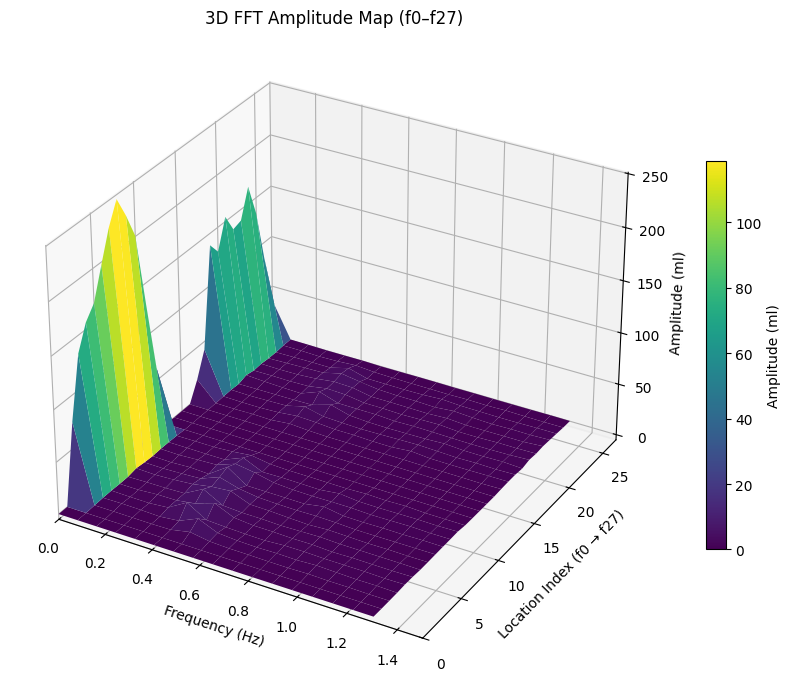

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# === Parameters ===
fs = 1000 / 350  # Hz
num_signals = 28   # f0 to f27

# === FFT setup using f[0] length ===
N = len(f[0])
freqs = np.fft.fftfreq(N, d=1/fs)
positive_freqs = freqs[:N//2]

# === Store FFT magnitudes ===
fft_matrix = np.zeros((num_signals, N//2))

for i in range(num_signals):
    signal = f[i]
    fft_vals = np.fft.fft(signal)
    magnitude = np.abs(fft_vals[:N//2]) / N
    fft_matrix[i, :] = magnitude

# === Create meshgrid ===
FREQ, LOC = np.meshgrid(positive_freqs, np.arange(num_signals))

# === 3D Plot ===
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    FREQ, LOC, fft_matrix,
    cmap='viridis',
    linewidth=0,
    antialiased=True
)

# === Labels ===
ax.set_title("3D FFT Amplitude Map (f0–f27)")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Location Index (f0 → f27)")
ax.set_zlabel("Amplitude (ml)")

ax.set_xlim(0, 1.5)   # respiratory + low-frequency focus
ax.set_ylim(0, num_signals - 1)

fig.colorbar(surf, ax=ax, shrink=0.6, label="Amplitude (ml)")

plt.tight_layout()
plt.savefig("3D_FFT_Frequency_Location_Amplitude.pdf", bbox_inches="tight")
plt.show()


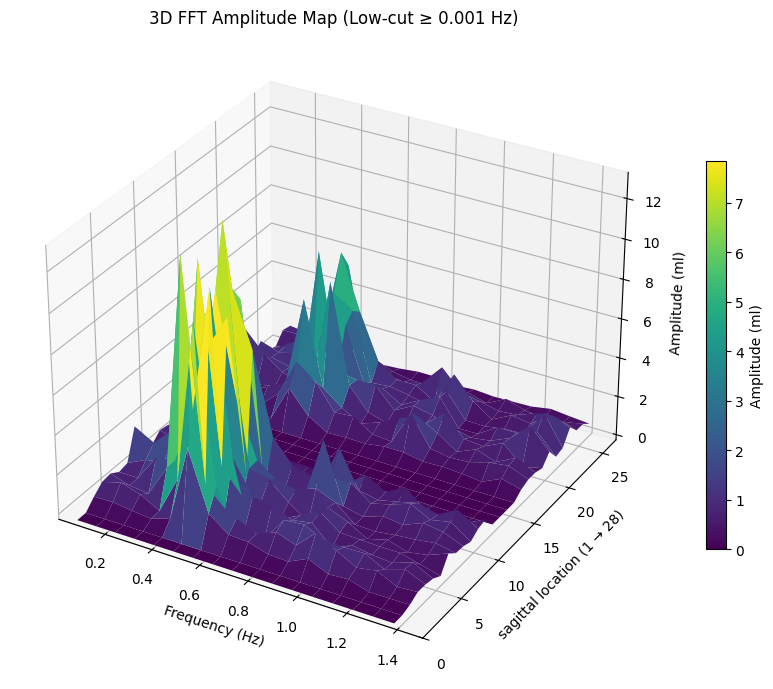

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# === Parameters ===
fs = 1000 / 350          # Hz
num_signals = 28         # f0 to f27
lowcut = 0.001           # Hz

# === FFT setup ===
N = len(f[0])
freqs = np.fft.fftfreq(N, d=1/fs)

# Positive frequencies only
positive_mask = freqs > 0
freqs_pos = freqs[positive_mask]

# Apply low-cut mask
freq_mask = freqs_pos >= lowcut
freqs_selected = freqs_pos[freq_mask]

# === Store FFT magnitudes ===
fft_matrix = np.zeros((num_signals, len(freqs_selected)))

for i in range(num_signals):
    signal = f[i]
    fft_vals = np.fft.fft(signal)
    magnitude = np.abs(fft_vals)[positive_mask] / N
    fft_matrix[i, :] = magnitude[freq_mask]

# === Meshgrid ===
FREQ, LOC = np.meshgrid(freqs_selected, np.arange(num_signals))

# === 3D Plot ===
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    FREQ, LOC, fft_matrix,
    cmap='viridis',
    linewidth=0,
    antialiased=True
)

# === Labels ===
ax.set_title("3D FFT Amplitude Map (Low-cut ≥ 0.001 Hz)")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("sagittal location (1 → 28)")
ax.set_zlabel("Amplitude (ml)")

ax.set_xlim(0.001, 1.5)
ax.set_ylim(0, num_signals - 1)

fig.colorbar(surf, ax=ax, shrink=0.6, label="Amplitude (ml)")

plt.tight_layout()
plt.savefig("3D_FFT_Map_Lowcut_0p001Hz.pdf", bbox_inches="tight")
plt.show()


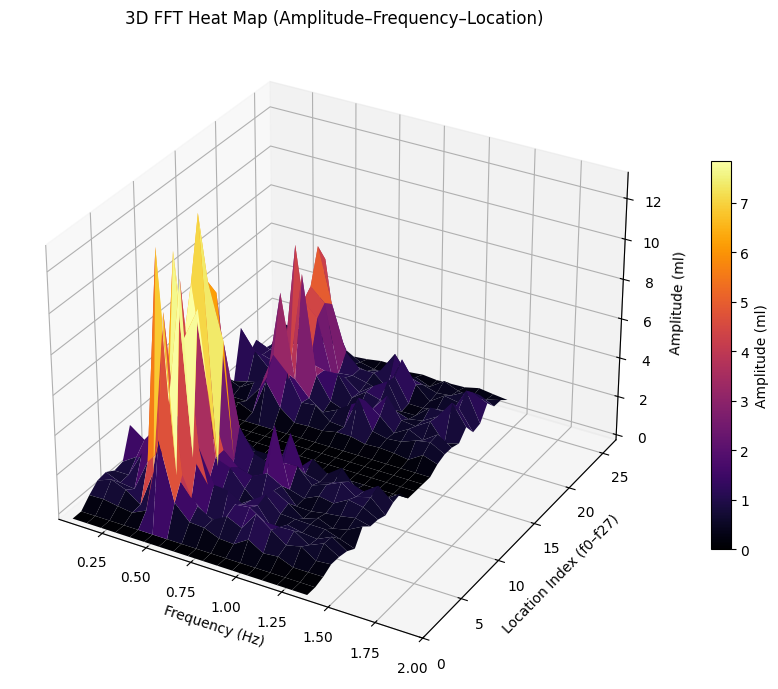

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# === Parameters ===
fs = 1000 / 350          # Hz
num_signals = 28         # f0 to f27
lowcut = 0.001           # Hz
highcut = 2.0            # Hz (focus range)

# === FFT setup ===
N = len(f[0])
freqs = np.fft.fftfreq(N, d=1/fs)

# Positive frequency mask + lowcut/highcut
freq_mask = (freqs >= lowcut) & (freqs <= highcut)
freqs_sel = freqs[freq_mask]

# === FFT amplitude matrix ===
fft_map = np.zeros((num_signals, len(freqs_sel)))

for i in range(num_signals):
    fft_vals = np.fft.fft(f[i])
    magnitude = np.abs(fft_vals) / N
    fft_map[i, :] = magnitude[freq_mask]

# === Meshgrid ===
FREQ, LOC = np.meshgrid(freqs_sel, np.arange(num_signals))

# === 3D Heat Map ===
fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection='3d')

surface = ax.plot_surface(
    FREQ, LOC, fft_map,
    cmap='inferno',      # good heatmap colormap
    edgecolor='none'
)

# === Labels ===
ax.set_title("3D FFT Heat Map (Amplitude–Frequency–Location)")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Location Index (f0–f27)")
ax.set_zlabel("Amplitude (ml)")

ax.set_xlim(lowcut, highcut)
ax.set_ylim(0, num_signals - 1)

# Colorbar
cbar = fig.colorbar(surface, ax=ax, shrink=0.6)
cbar.set_label("Amplitude (ml)")

plt.tight_layout()
plt.savefig("3D_FFT_Heatmap_Amplitude_Frequency.pdf", bbox_inches="tight")
plt.show()


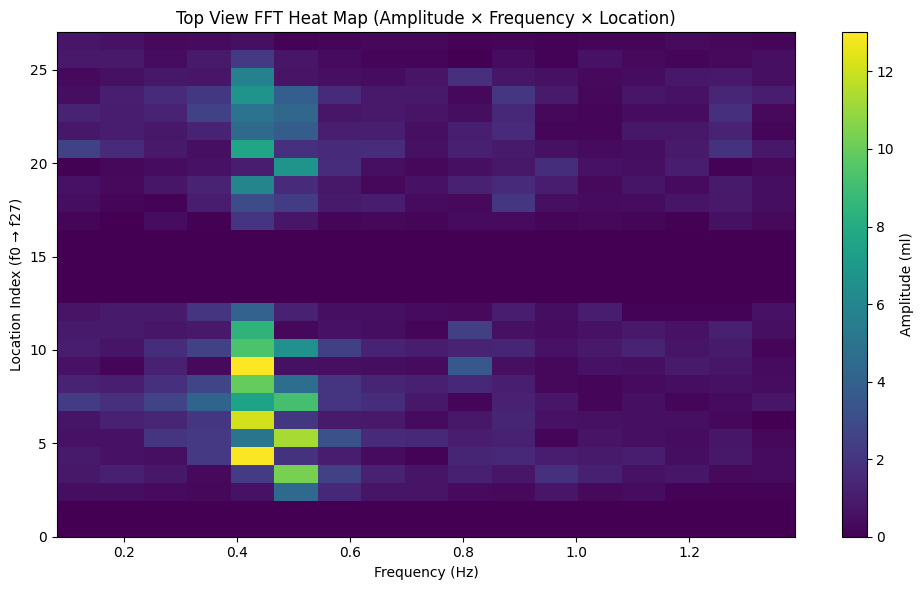

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# === Parameters ===
fs = 1000 / 350          # Hz
num_signals = 28         # f0 to f27
lowcut = -0.0001           # Hz
highcut = 2.0            # Hz (display limit)

# === FFT setup ===
N = len(f[0])
freqs = np.fft.fftfreq(N, d=1/fs)

# Positive frequencies
pos_mask = freqs > 0
freqs_pos = freqs[pos_mask]

# Frequency selection
freq_mask = (freqs_pos >= lowcut) & (freqs_pos <= highcut)
freqs_sel = freqs_pos[freq_mask]

# === FFT magnitude matrix ===
fft_map = np.zeros((num_signals, len(freqs_sel)))

for i in range(num_signals):
    fft_vals = np.fft.fft(f[i])
    mag = np.abs(fft_vals)[pos_mask] / N
    fft_map[i, :] = mag[freq_mask]

# === Plot: Top View Heatmap ===
plt.figure(figsize=(10, 6))

plt.imshow(
    fft_map,
    aspect='auto',
    origin='lower',
    extent=[
        freqs_sel[0], freqs_sel[-1],   # Frequency axis
        0, num_signals - 1              # Location axis
    ],
    cmap='viridis'
)

plt.colorbar(label="Amplitude (ml)")

plt.xlabel("Frequency (Hz)")
plt.ylabel("Location Index (f0 → f27)")
plt.title("Top View FFT Heat Map (Amplitude × Frequency × Location)")

plt.tight_layout()
plt.savefig("Top_View_FFT_Heatmap.pdf", bbox_inches="tight")
plt.show()


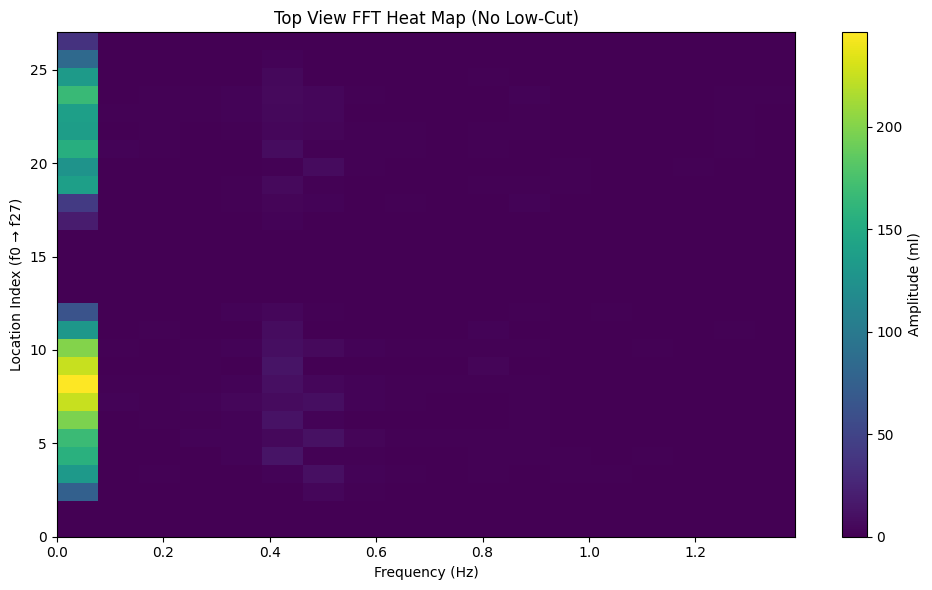

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# === Parameters ===
fs = 1000 / 350          # Hz
num_signals = 28         # f0 to f27
highcut = 2.0            # Hz (display limit only)

# === FFT setup ===
N = len(f[0])
freqs = np.fft.fftfreq(N, d=1/fs)

# Keep positive frequencies INCLUDING DC (0 Hz)
pos_mask = freqs >= 0
freqs_pos = freqs[pos_mask]

# Limit display range (optional)
freq_mask = freqs_pos <= highcut
freqs_sel = freqs_pos[freq_mask]

# === FFT magnitude matrix ===
fft_map = np.zeros((num_signals, len(freqs_sel)))

for i in range(num_signals):
    fft_vals = np.fft.fft(f[i])
    mag = np.abs(fft_vals)[pos_mask] / N
    fft_map[i, :] = mag[freq_mask]

# === Plot: Top View Heatmap ===
plt.figure(figsize=(10, 6))

plt.imshow(
    fft_map,
    aspect='auto',
    origin='lower',
    extent=[
        freqs_sel[0], freqs_sel[-1],   # Frequency axis (includes 0 Hz)
        0, num_signals - 1             # Location axis
    ],
    cmap='viridis'
)

plt.colorbar(label="Amplitude (ml)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Location Index (f0 → f27)")
plt.title("Top View FFT Heat Map (No Low-Cut)")

plt.tight_layout()
plt.savefig("Top_View_FFT_Heatmap_NoLowcut.pdf", bbox_inches="tight")
plt.show()


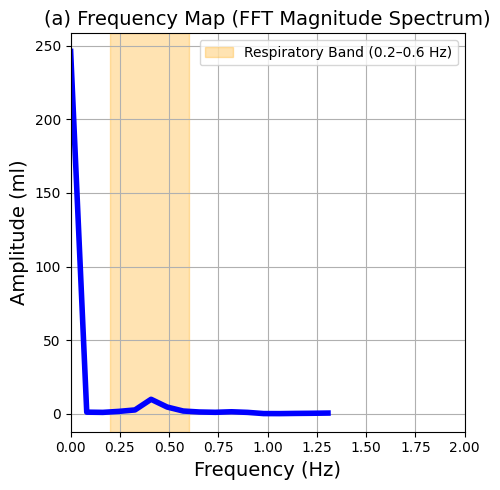

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# === Your signal ===
signal = f[8]
fs = 1000 / 350  # sampling frequency (Hz)

N = len(signal)

# === FFT ===
fft_vals = np.fft.fft(signal)
freqs = np.fft.fftfreq(N, d=1/fs)

# === Use only positive frequencies ===
positive_freqs = freqs[:N//2]
magnitude = np.abs(fft_vals[:N//2]) / N

# === Plot frequency map ===
plt.figure(figsize=(5, 5))
plt.plot(positive_freqs, magnitude, color='blue', linewidth=4)

# Highlight respiratory band
plt.axvspan(0.2, 0.6, color='orange', alpha=0.3, label='Respiratory Band (0.2–0.6 Hz)')

plt.title("(a) Frequency Map (FFT Magnitude Spectrum)", fontsize=14)
plt.xlabel("Frequency (Hz)", fontsize=14)
plt.ylabel("Amplitude (ml)", fontsize=14)

plt.xlim(0, 2)   # adjust if needed
plt.grid(True)
plt.legend()
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig("Frequency_Map_FFT.pdf", bbox_inches="tight")
plt.show()


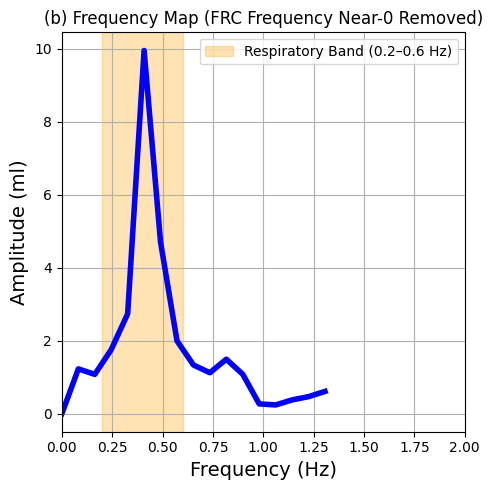

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# === Signal ===
signal = f[8]
fs = 1000 / 350  # Hz
N = len(signal)

# === FFT ===
fft_vals = np.fft.fft(signal)
freqs = np.fft.fftfreq(N, d=1/fs)

# === Remove frequencies close to 0 Hz ===
low_freq_cutoff = 1/(24*3600)  # Hz (adjust: 0.03–0.1 typical for respiration)
mask = np.abs(freqs) >= low_freq_cutoff

fft_cleaned = fft_vals * mask

# === Magnitude spectrum (positive frequencies only) ===
positive_freqs = freqs[:N//2]
magnitude = np.abs(fft_cleaned[:N//2]) / N

# === Plot frequency map ===
plt.figure(figsize=(5, 5))
plt.plot(positive_freqs, magnitude, color='blue', linewidth=4)

plt.axvspan(0.2, 0.6, color='orange', alpha=0.3,
            label='Respiratory Band (0.2–0.6 Hz)')

plt.title("(b) Frequency Map (FRC Frequency Near-0 Removed)", fontsize=12)
plt.xlabel("Frequency (Hz)", fontsize=14)
plt.ylabel("Amplitude (ml)", fontsize=14)

plt.xlim(0, 2)   # adjust if needed
plt.grid(True)
plt.legend()
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig("Frequency_Map_FFT.pdf", bbox_inches="tight")
plt.show()


C:\Users\resea\AppData\Local\Temp\ipykernel_66212\2533603294.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\resea\AppData\Local\Temp\ipykernel_66212\2533603294.py:57: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\resea\AppData\Local\Temp\ipykernel_66212\2533603294.py:70: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


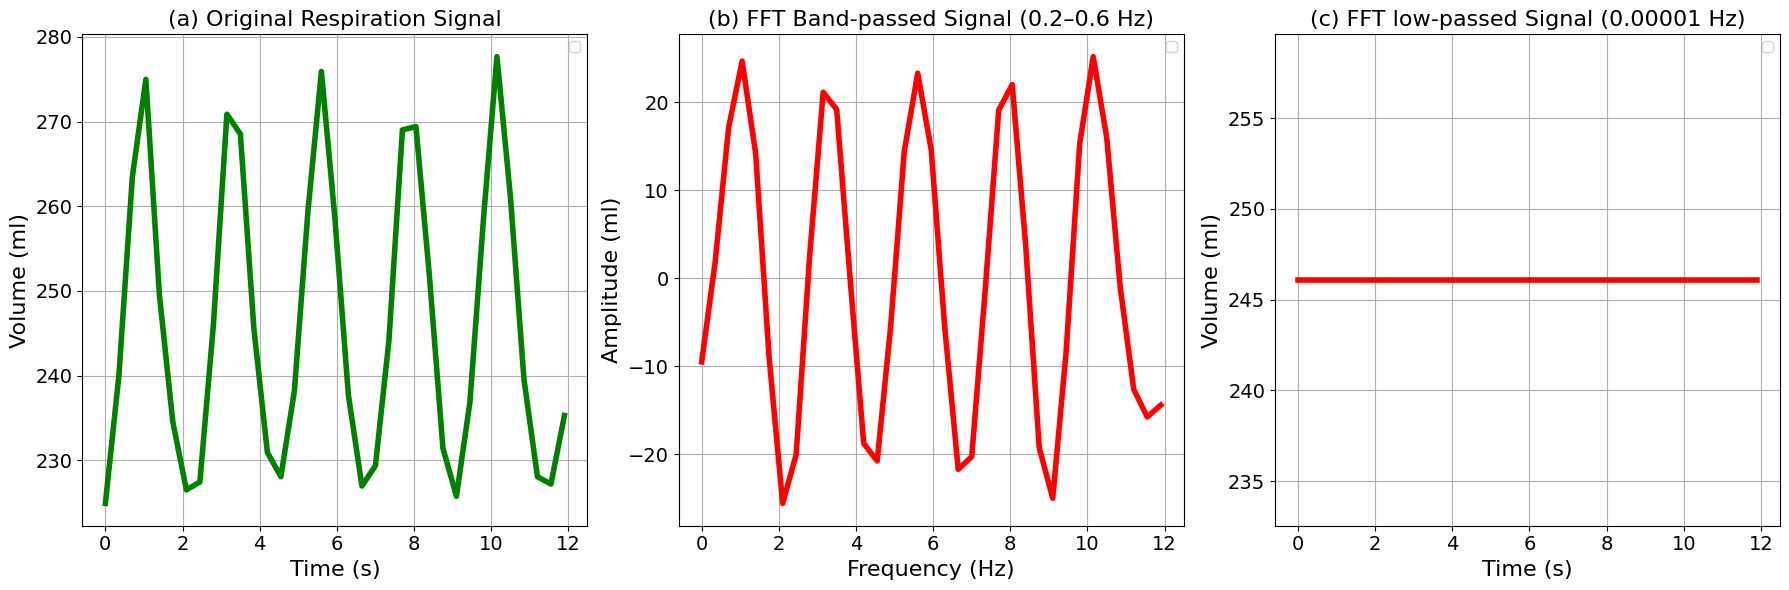

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# === Your actual data array ===
total_white_points = f[8]   # your signal
sample_rate = 1000 / 350   # Hz

# === Time axis ===
N = len(total_white_points)
duration = N / sample_rate
time_original = np.linspace(0, duration, N, endpoint=False)

# === FFT ===
fft_vals = np.fft.fft(total_white_points)
freqs = np.fft.fftfreq(N, d=1/sample_rate)

# === Bandpass mask (0.2–0.6 Hz) ===
cutoff = 0.0001

low_mask = (np.abs(freqs) <= cutoff)
fft_low = fft_vals * low_mask

# === Inverse FFT ===
signal_lowfiltered = np.real(np.fft.ifft(fft_low))

# === Bandpass mask (0.2–0.6 Hz) ===
lowcut = 0.2
highcut = 0.6

band_mask = (np.abs(freqs) >= lowcut) & (np.abs(freqs) <= highcut)

# Apply mask
fft_filtered = fft_vals * band_mask

# === Inverse FFT ===
signal_filtered = np.real(np.fft.ifft(fft_filtered))

# === Plot ===
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.plot(time_original, total_white_points, 'g', linewidth=4.0)
plt.title("(a) Original Respiration Signal", fontsize=16)
plt.xlabel("Time (s)", fontsize=16)
plt.ylabel("Volume (ml)", fontsize=16)
plt.grid(True)
plt.legend()
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.subplot(1, 3, 3)
plt.plot(time_original, signal_lowfiltered, 'red', linewidth=4.0)
plt.title("(c) FFT low-passed Signal (0.00001 Hz)", fontsize=16)
plt.ylabel("Volume (ml)", fontsize=16)
plt.xlabel("Time (s)", fontsize=16)
plt.grid(True)
plt.legend()
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.subplot(1, 3, 2)
plt.plot(time_original, signal_filtered, 'red', linewidth=4.0)
plt.title("(b) FFT Band-passed Signal (0.2–0.6 Hz)", fontsize=16)
plt.xlabel("Time (s)")
plt.ylabel("Volume (ml)")
plt.grid(True)
plt.xlabel("Frequency (Hz)", fontsize=16)
plt.ylabel("Amplitude (ml)", fontsize=16)

plt.legend()
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.savefig("output.png", dpi=300, bbox_inches="tight")
plt.show()


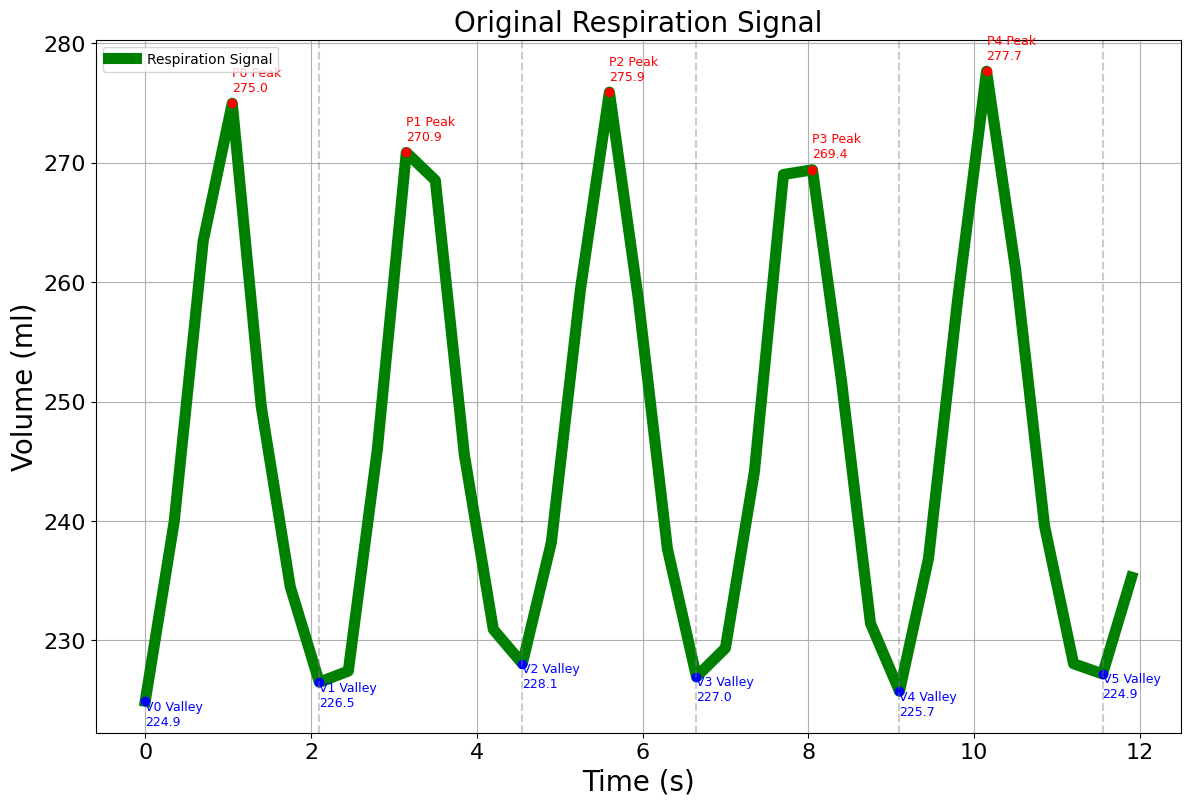

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# === Signal ===
signal = total_white_points          # or signal_filtered
fs = sample_rate

# === Time axis ===
N = len(signal)
time = np.arange(N) / fs

# === Detect peaks and valleys ===
peaks, _ = find_peaks(signal, distance=fs*1.0)
valleys, _ = find_peaks(-signal, distance=fs*1.0)

valleys = np.sort(valleys)

plt.figure(figsize=(14,9))
# plt.ylim(0, 285)
plt.plot(time, signal, 'g', label='Respiration Signal', linewidth=8)

# === C0: zero-time point ===
t0_idx = 0
t0_val = signal[t0_idx]

plt.plot(time[t0_idx], t0_val, 'bo')
plt.text(time[t0_idx], t0_val - 2,
         f'V0 Valley\n{t0_val:.1f}',
         ha='left', fontsize=9, color='blue')

# === C0 Peak (first detected peak) ===
if len(peaks) > 0:
    c0_peak_idx = peaks[0]
    c0_peak_val = signal[c0_peak_idx]

    plt.plot(time[c0_peak_idx], c0_peak_val, 'ro')
    plt.text(time[c0_peak_idx], c0_peak_val + 1,
             f'P0 Peak\n{c0_peak_val:.1f}',
             ha='left', fontsize=9, color='red')

# === Plot remaining cycles (C1, C2, ...) ===
for i in range(len(valleys) - 1):
    start = valleys[i]
    end = valleys[i + 1]

    p_in_cycle = peaks[(peaks > start) & (peaks < end)]
    if len(p_in_cycle) == 0:
        continue

    peak_idx = p_in_cycle[np.argmax(signal[p_in_cycle])]
    valley_idx = start

    plt.plot(time[valley_idx], signal[valley_idx], 'bo')
    plt.plot(time[peak_idx], signal[peak_idx], 'ro')

    plt.text(time[peak_idx], signal[peak_idx] + 1,
             f'P{i+1} Peak\n{signal[peak_idx]:.1f}',
             ha='left', fontsize=9, color='red')

    plt.text(time[valley_idx], signal[valley_idx] - 2,
             f'V{i+1} Valley\n{signal[valley_idx]:.1f}',
             ha='left', fontsize=9, color='blue')

    plt.axvline(time[valley_idx], color='gray', linestyle='--', alpha=0.4)

# Last boundary
if len(valleys) > 0:
    plt.text(time[valleys[-1]], signal[33] - 2,
         f'V5 Valley\n{t0_val:.1f}',
         ha='left', fontsize=9, color='blue')
    plt.plot(time[valleys[-1]], signal[33], 'bo')
    plt.axvline(time[valleys[-1]], color='gray', linestyle='--', alpha=0.4)

# === Formatting ===
plt.title("Original Respiration Signal", fontsize=20)
plt.xlabel("Time (s)", fontsize=20)
plt.ylabel("Volume (ml)", fontsize=20)
import matplotlib.pyplot as plt


# Set x-axis and y-axis tick labels font size
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.legend()
plt.grid(True)
plt.savefig("high_resolution_plot.png", dpi=300, bbox_inches="tight")
plt.show()


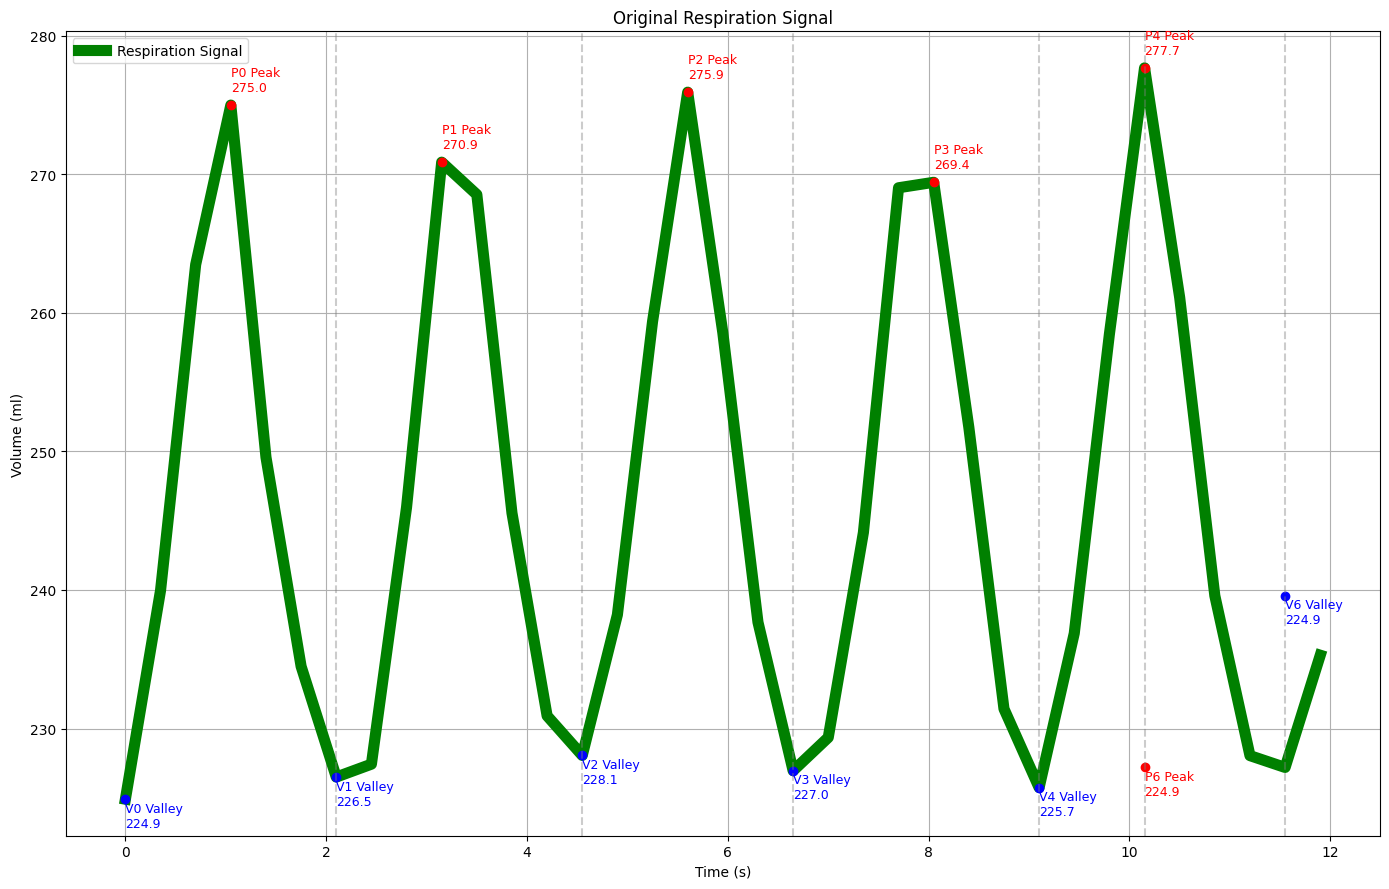

In [ ]:
total_white_points = f[8]   # your signal
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# === Signal ===
signal = total_white_points          # or signal_filtered
fs = sample_rate

# === Time axis ===
N = len(signal)
time = np.arange(N) / fs

# === Detect peaks and valleys ===
peaks, _ = find_peaks(signal, distance=fs*1.0)
valleys, _ = find_peaks(-signal, distance=fs*1.0)

valleys = np.sort(valleys)

plt.figure(figsize=(14,9))
# plt.ylim(0, 285)
plt.plot(time, signal, 'g', label='Respiration Signal', linewidth=8)

# === C0: zero-time point ===
t0_idx = 0
t0_val = signal[t0_idx]

plt.plot(time[t0_idx], t0_val, 'bo')
plt.text(time[t0_idx], t0_val - 2,
         f'V0 Valley\n{t0_val:.1f}',
         ha='left', fontsize=9, color='blue')

# === C0 Peak (first detected peak) ===
if len(peaks) > 0:
    c0_peak_idx = peaks[0]
    c0_peak_val = signal[c0_peak_idx]

    plt.plot(time[c0_peak_idx], c0_peak_val, 'ro')
    plt.text(time[c0_peak_idx], c0_peak_val + 1,
             f'P0 Peak\n{c0_peak_val:.1f}',
             ha='left', fontsize=9, color='red')

# === Plot remaining cycles (C1, C2, ...) ===
for i in range(len(valleys) - 1):
    start = valleys[i]
    end = valleys[i + 1]

    p_in_cycle = peaks[(peaks > start) & (peaks < end)]
    if len(p_in_cycle) == 0:
        continue

    peak_idx = p_in_cycle[np.argmax(signal[p_in_cycle])]
    valley_idx = start

    plt.plot(time[valley_idx], signal[valley_idx], 'bo')
    plt.plot(time[peak_idx], signal[peak_idx], 'ro')

    plt.text(time[peak_idx], signal[peak_idx] + 1,
             f'P{i+1} Peak\n{signal[peak_idx]:.1f}',
             ha='left', fontsize=9, color='red')

    plt.text(time[valley_idx], signal[valley_idx] - 2,
             f'V{i+1} Valley\n{signal[valley_idx]:.1f}',
             ha='left', fontsize=9, color='blue')

    plt.axvline(time[valley_idx], color='gray', linestyle='--', alpha=0.4)

# Last boundary
if len(valleys) > 0:
    plt.text(time[valleys[-1]], signal[31] - 2,
         f'V6 Valley\n{t0_val:.1f}',
         ha='left', fontsize=9, color='blue')
    plt.plot(time[valleys[-1]], signal[31], 'bo')
    plt.axvline(time[valleys[-1]], color='gray', linestyle='--', alpha=0.4)
    # Last boundary
if len(peaks) > 0:
    plt.text(time[peaks[-1]], signal[33] - 2,
         f'P6 Peak\n{t0_val:.1f}',
         ha='left', fontsize=9, color='red')
    plt.plot(time[peaks[-1]], signal[33], 'ro')
    plt.axvline(time[peaks[-1]], color='gray', linestyle='--', alpha=0.4)

# === Formatting ===
plt.title("Original Respiration Signal")
plt.xlabel("Time (s)")
plt.ylabel("Volume (ml)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


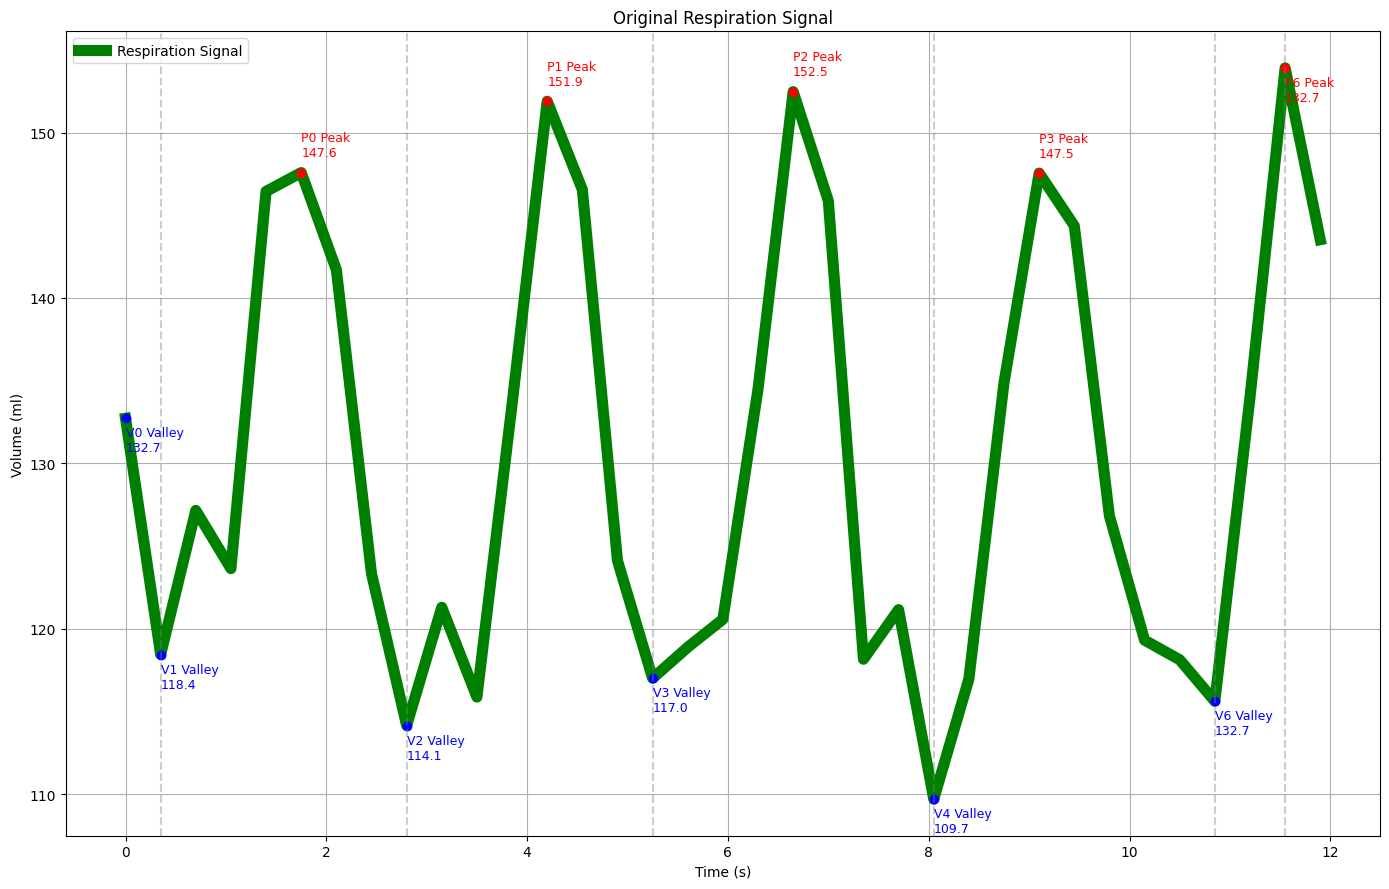

In [13]:
total_white_points = f[11]   # your signal
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# === Signal ===
signal = total_white_points          # or signal_filtered
fs = sample_rate

# === Time axis ===
N = len(signal)
time = np.arange(N) / fs

# === Detect peaks and valleys ===
peaks, _ = find_peaks(signal, distance=fs*1.0)
valleys, _ = find_peaks(-signal, distance=fs*1.0)

valleys = np.sort(valleys)

plt.figure(figsize=(14,9))
# plt.ylim(0, 285)
plt.plot(time, signal, 'g', label='Respiration Signal', linewidth=8)

# === C0: zero-time point ===
t0_idx = 0
t0_val = signal[t0_idx]

plt.plot(time[t0_idx], t0_val, 'bo')
plt.text(time[t0_idx], t0_val - 2,
         f'V0 Valley\n{t0_val:.1f}',
         ha='left', fontsize=9, color='blue')

# === C0 Peak (first detected peak) ===
# if len(peaks) > 0:
#     c0_peak_idx = peaks[0]
#     c0_peak_val = signal[c0_peak_idx]

#     plt.plot(time[c0_peak_idx], c0_peak_val, 'ro')
#     plt.text(time[c0_peak_idx], c0_peak_val + 1,
#              f'P0 Peak\n{c0_peak_val:.1f}',
#              ha='left', fontsize=9, color='red')

# === Plot remaining cycles (C1, C2, ...) ===
for i in range(len(valleys) - 1):
    start = valleys[i]
    end = valleys[i + 1]

    p_in_cycle = peaks[(peaks > start) & (peaks < end)]
    if len(p_in_cycle) == 0:
        continue

    peak_idx = p_in_cycle[np.argmax(signal[p_in_cycle])]
    valley_idx = start

    plt.plot(time[valley_idx], signal[valley_idx], 'bo')
    plt.plot(time[peak_idx], signal[peak_idx], 'ro')

    plt.text(time[peak_idx], signal[peak_idx] + 1,
             f'P{i} Peak\n{signal[peak_idx]:.1f}',
             ha='left', fontsize=9, color='red')

    plt.text(time[valley_idx], signal[valley_idx] - 2,
             f'V{i+1} Valley\n{signal[valley_idx]:.1f}',
             ha='left', fontsize=9, color='blue')

    plt.axvline(time[valley_idx], color='gray', linestyle='--', alpha=0.4)

# Last boundary
if len(valleys) > 0:
    plt.text(time[valleys[-1]], signal[31] - 2,
         f'V6 Valley\n{t0_val:.1f}',
         ha='left', fontsize=9, color='blue')
    plt.plot(time[valleys[-1]], signal[31], 'bo')
    plt.axvline(time[valleys[-1]], color='gray', linestyle='--', alpha=0.4)
    # Last boundary
if len(peaks) > 0:
    plt.text(time[peaks[-1]], signal[33] - 2,
         f'P6 Peak\n{t0_val:.1f}',
         ha='left', fontsize=9, color='red')
    plt.plot(time[peaks[-1]], signal[33], 'ro')
    plt.axvline(time[peaks[-1]], color='gray', linestyle='--', alpha=0.4)

# === Formatting ===
plt.title("Original Respiration Signal")
plt.xlabel("Time (s)")
plt.ylabel("Volume (ml)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


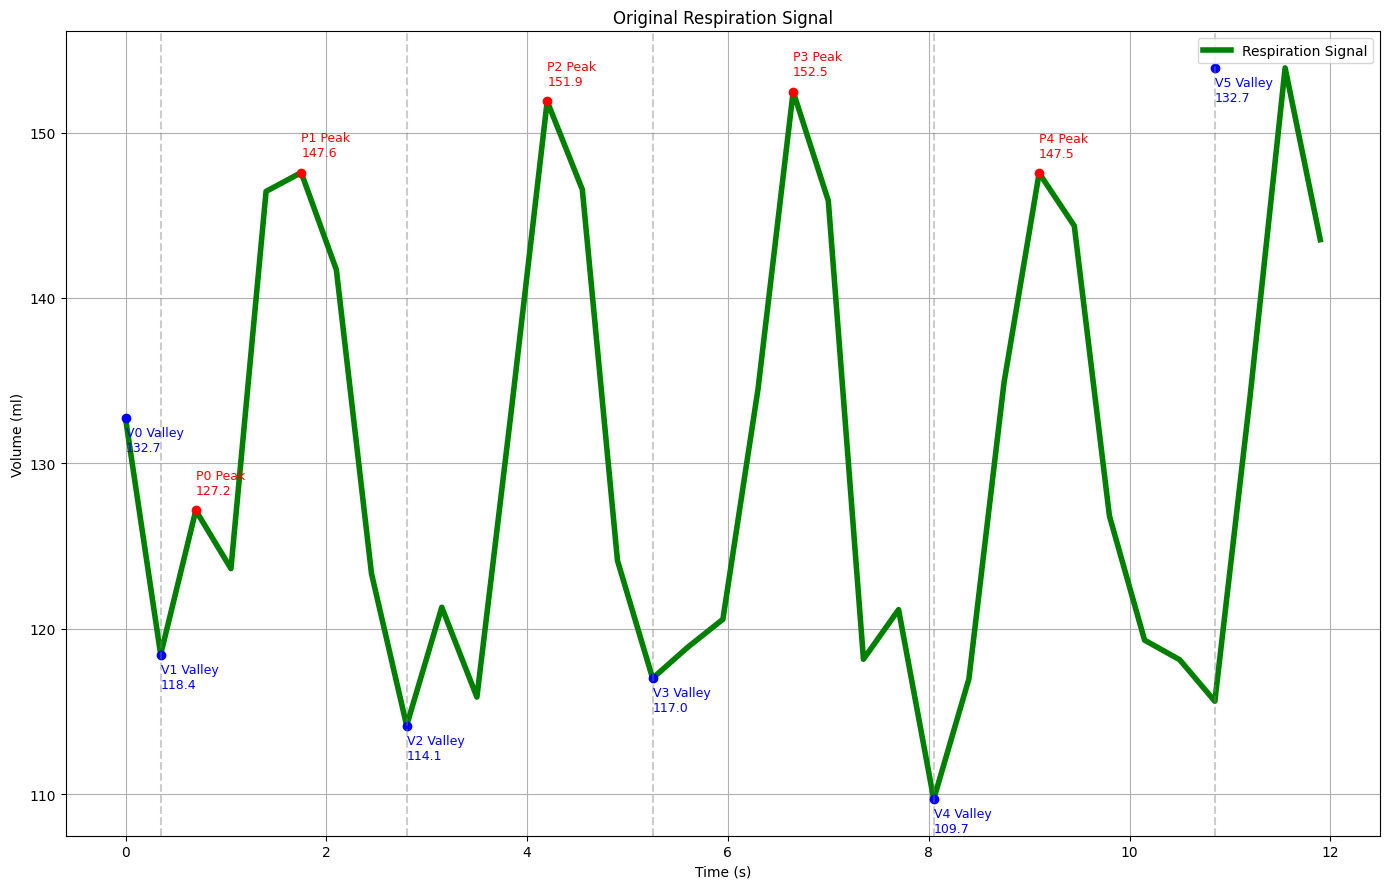

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# === Signal ===
signal = total_white_points          # or signal_filtered
fs = sample_rate

# === Time axis ===
N = len(signal)
time = np.arange(N) / fs

# === Detect peaks and valleys ===
peaks, _ = find_peaks(signal, distance=fs*1.0)
valleys, _ = find_peaks(-signal, distance=fs*1.0)

valleys = np.sort(valleys)

plt.figure(figsize=(14,9))
# plt.ylim(0, 285)
plt.plot(time, signal, 'g', label='Respiration Signal', linewidth=4)

# === C0: zero-time point ===
t0_idx = 0
t0_val = signal[t0_idx]

plt.plot(time[t0_idx], t0_val, 'bo')
plt.text(time[t0_idx], t0_val - 2,
         f'V0 Valley\n{t0_val:.1f}',
         ha='left', fontsize=9, color='blue')

# === C0 Peak (first detected peak) ===
if len(peaks) > 0:
    c0_peak_idx = peaks[0]
    c0_peak_val = signal[c0_peak_idx]

    plt.plot(time[c0_peak_idx], c0_peak_val, 'ro')
    plt.text(time[c0_peak_idx], c0_peak_val + 1,
             f'P0 Peak\n{c0_peak_val:.1f}',
             ha='left', fontsize=9, color='red')

# === Plot remaining cycles (C1, C2, ...) ===
for i in range(len(valleys) - 1):
    start = valleys[i]
    end = valleys[i + 1]

    p_in_cycle = peaks[(peaks > start) & (peaks < end)]
    if len(p_in_cycle) == 0:
        continue

    peak_idx = p_in_cycle[np.argmax(signal[p_in_cycle])]
    valley_idx = start

    plt.plot(time[valley_idx], signal[valley_idx], 'bo')
    plt.plot(time[peak_idx], signal[peak_idx], 'ro')

    plt.text(time[peak_idx], signal[peak_idx] + 1,
             f'P{i+1} Peak\n{signal[peak_idx]:.1f}',
             ha='left', fontsize=9, color='red')

    plt.text(time[valley_idx], signal[valley_idx] - 2,
             f'V{i+1} Valley\n{signal[valley_idx]:.1f}',
             ha='left', fontsize=9, color='blue')

    plt.axvline(time[valley_idx], color='gray', linestyle='--', alpha=0.4)

# Last boundary
if len(valleys) > 0:
    plt.text(time[valleys[-1]], signal[33] - 2,
         f'V5 Valley\n{t0_val:.1f}',
         ha='left', fontsize=9, color='blue')
    plt.plot(time[valleys[-1]], signal[33], 'bo')
    plt.axvline(time[valleys[-1]], color='gray', linestyle='--', alpha=0.4)

# === Formatting ===
plt.title("Original Respiration Signal")
plt.xlabel("Time (s)")
plt.ylabel("Volume (ml)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Number of IMFs: 3


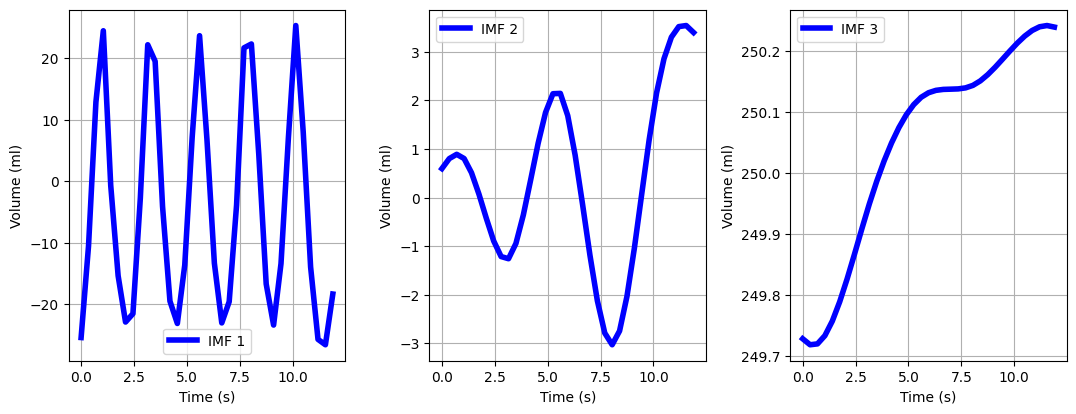

In [15]:
import numpy as np
from scipy import signal
from PyEMD import EMD
import matplotlib.pyplot as plt

# === Your actual data array ===
total_white_points = f[8]   # your signal
sample_rate = 1000 / 350   # Hz

# === Time axis ===
N = len(total_white_points)
duration = N / sample_rate
time_original = np.linspace(0, duration, N, endpoint=False)

# === FFT ===
fft_vals = np.fft.fft(total_white_points)
freqs = np.fft.fftfreq(N, d=1/sample_rate)

# === Bandpass mask (0.2–0.6 Hz) ===
cutoff = 0.0001

low_mask = (np.abs(freqs) <= cutoff)
fft_low = fft_vals * low_mask

# === Inverse FFT ===
signal_lowfiltered = np.real(np.fft.ifft(fft_low))

# === Bandpass mask (0.2–0.6 Hz) ===
lowcut = 0.2
highcut = 0.6

band_mask = (np.abs(freqs) >= lowcut) & (np.abs(freqs) <= highcut)

# Apply mask
fft_filtered = fft_vals * band_mask

# === Inverse FFT ===
signal_filtered1 = np.real(np.fft.ifft(fft_filtered))

# === Step 1: Apply EMD ===

emd = EMD()
imfs = emd(f[8])
num_imfs = imfs.shape[0]
print("Number of IMFs:", num_imfs)

# === FFT ===

freqs = np.fft.fftfreq(N, d=1/sample_rate)

# === Bandpass mask (0.2–0.6 Hz) ===
lowcut = 0.05
highcut = 1

band_mask = (np.abs(freqs) >= lowcut) & (np.abs(freqs) <= highcut)

# Apply mask
fft_filtered = fft_vals * band_mask

# # === Inverse FFT ===
# signal_filtered = np.real(np.fft.ifft(fft_filtered))





# === Step 5: Plot original + filtered IMFs ===
plt.figure(figsize=(2.5 * (num_imfs + 4), 12))

# # Original Signal
# plt.subplot(3, num_imfs + 4, 1)
# plt.plot(time_original, total_white_points, 'g')
# plt.title("Original Signal")
# plt.xlabel("Time (s)")
# plt.grid(True)

# IMFs (filtered)
for i in range(num_imfs):
    plt.subplot(3, num_imfs + 2, i + 2)
    fft_vals = np.fft.fft(imfs[i])
    signal_filt = fft_vals * band_mask
    signal_filtered = np.real(np.fft.ifft(signal_filt))
    # if i == 0:
    #     plt.plot(time_original, signal_filtered1, 'red')
    # if i == 2:
    #     plt.plot(time_original, signal_lowfiltered, 'red')        
    
    # plt.plot(time_original, signal_filtered, label=f"IMF {i+1} Filtered", color='orange')
    plt.plot(time_original, imfs[i], label=f"IMF {i+1}", color='blue', linewidth=4)
    plt.legend()
    plt.xlabel("Time (s)")
    plt.ylabel("Volume (ml)")
    plt.grid(True)

# Save and show
plt.tight_layout()
plt.savefig("Filtered_IMFs_Above_0.2Hz - 0.6 Hz.pdf", format="pdf", bbox_inches="tight")
plt.show()


Number of IMFs: 3


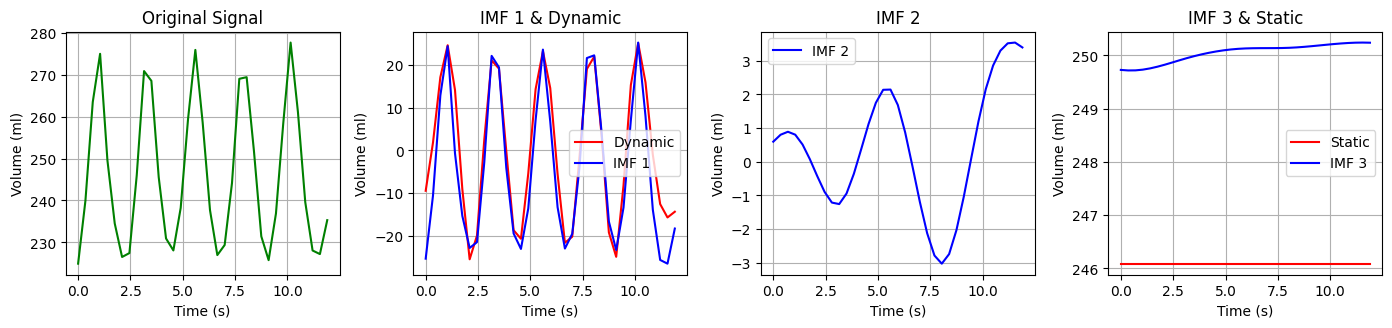

In [16]:
import numpy as np
from scipy import signal
from PyEMD import EMD
import matplotlib.pyplot as plt

# === Your actual data array ===
total_white_points = f[8]   # your signal
sample_rate = 1000 / 350   # Hz

# === Time axis ===
N = len(total_white_points)
duration = N / sample_rate
time_original = np.linspace(0, duration, N, endpoint=False)

# === FFT ===
fft_vals = np.fft.fft(total_white_points)
freqs = np.fft.fftfreq(N, d=1/sample_rate)

# === Bandpass mask (0.2–0.6 Hz) ===
cutoff = 0.0001

low_mask = (np.abs(freqs) <= cutoff)
fft_low = fft_vals * low_mask

# === Inverse FFT ===
signal_lowfiltered = np.real(np.fft.ifft(fft_low))

# === Bandpass mask (0.2–0.6 Hz) ===
lowcut = 0.2
highcut = 0.6

band_mask = (np.abs(freqs) >= lowcut) & (np.abs(freqs) <= highcut)

# Apply mask
fft_filtered = fft_vals * band_mask

# === Inverse FFT ===
signal_filtered1 = np.real(np.fft.ifft(fft_filtered))

# === Step 1: Apply EMD ===

emd = EMD()
imfs = emd(f[8])
num_imfs = imfs.shape[0]
print("Number of IMFs:", num_imfs)

# === FFT ===

freqs = np.fft.fftfreq(N, d=1/sample_rate)

# === Bandpass mask (0.2–0.6 Hz) ===
lowcut = 0.2
highcut = 0.6

band_mask = (np.abs(freqs) >= lowcut) & (np.abs(freqs) <= highcut)

# Apply mask
fft_filtered = fft_vals * band_mask

# # === Inverse FFT ===
# signal_filtered = np.real(np.fft.ifft(fft_filtered))
# === Step 5: Plot original + filtered IMFs ===
plt.figure(figsize=(2.5 * (num_imfs + 4), 12))

# Original Signal
plt.subplot(4, num_imfs + 2, 1)
plt.plot(time_original, total_white_points, 'g')
plt.title("Original Signal")
plt.xlabel("Time (s)")
plt.ylabel("Volume (ml)")
plt.grid(True)

# IMFs (filtered)
for i in range(num_imfs):
    plt.subplot(4, num_imfs + 2, i + 2)
    fft_vals = np.fft.fft(imfs[i])
    signal_filt = fft_vals * band_mask
    signal_filtered = np.real(np.fft.ifft(signal_filt))
    plt.title(f"IMF {i+1}")
    if i == 0:
        plt.plot(time_original, signal_filtered1, label="Dynamic", color='red')
        plt.title(f"IMF {i+1} & Dynamic")
    if i == 2:
        plt.plot(time_original, signal_lowfiltered, label="Static", color='red')
        plt.title(f"IMF {i+1} & Static")             
    
    # plt.plot(time_original, signal_filtered, label=f"IMF {i+1} Filtered", color='orange')
    plt.plot(time_original, imfs[i], label=f"IMF {i+1}", color='blue')
    plt.legend()
    plt.xlabel("Time (s)")
    plt.ylabel("Volume (ml)")
    plt.grid(True)

# Save and show
plt.tight_layout()
plt.savefig("Filtered_IMFs_Above_0.2Hz - 0.6 Hz.pdf", format="pdf", bbox_inches="tight")
plt.show()


Number of IMFs: 3


C:\Users\resea\AppData\Local\Temp\ipykernel_54184\676312300.py:93: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


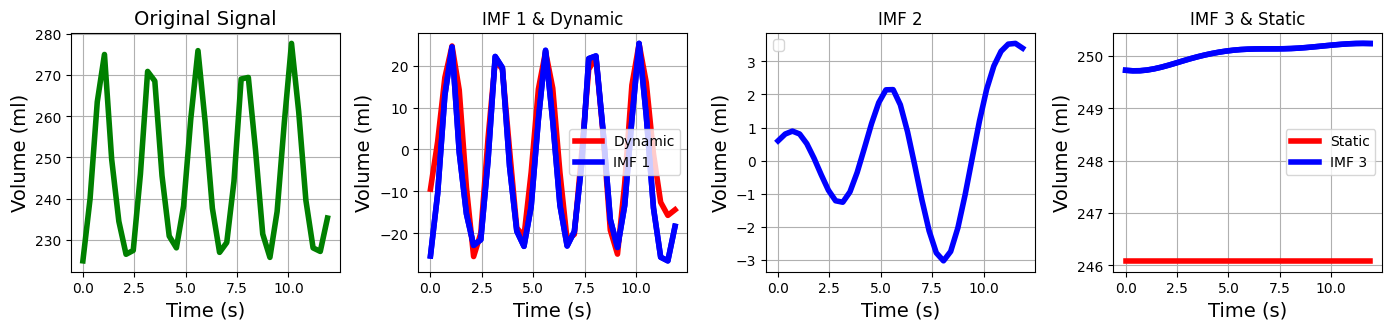

In [10]:
import numpy as np
from scipy import signal
from PyEMD import EMD
import matplotlib.pyplot as plt

# === Your actual data array ===
total_white_points = f[8]   # your signal
sample_rate = 1000 / 350   # Hz

# === Time axis ===
N = len(total_white_points)
duration = N / sample_rate
time_original = np.linspace(0, duration, N, endpoint=False)

# === FFT ===
fft_vals = np.fft.fft(total_white_points)
freqs = np.fft.fftfreq(N, d=1/sample_rate)

# === Bandpass mask (0.2–0.6 Hz) ===
cutoff = 0.0001

low_mask = (np.abs(freqs) <= cutoff)
fft_low = fft_vals * low_mask

# === Inverse FFT ===
signal_lowfiltered = np.real(np.fft.ifft(fft_low))

# === Bandpass mask (0.2–0.6 Hz) ===
lowcut = 0.2
highcut = 0.6

band_mask = (np.abs(freqs) >= lowcut) & (np.abs(freqs) <= highcut)

# Apply mask
fft_filtered = fft_vals * band_mask

# === Inverse FFT ===
signal_filtered1 = np.real(np.fft.ifft(fft_filtered))

# === Step 1: Apply EMD ===

emd = EMD()
imfs = emd(f[8])
num_imfs = imfs.shape[0]
print("Number of IMFs:", num_imfs)

# === FFT ===

freqs = np.fft.fftfreq(N, d=1/sample_rate)

# === Bandpass mask (0.2–0.6 Hz) ===
lowcut = 0.2
highcut = 0.6

band_mask = (np.abs(freqs) >= lowcut) & (np.abs(freqs) <= highcut)

# Apply mask
fft_filtered = fft_vals * band_mask

# # === Inverse FFT ===
# signal_filtered = np.real(np.fft.ifft(fft_filtered))
# === Step 5: Plot original + filtered IMFs ===
plt.figure(figsize=(2.5 * (num_imfs + 4), 12))

# Original Signal
plt.subplot(4, num_imfs + 2, 1)
plt.plot(time_original, total_white_points, 'g', linewidth=4)
plt.title("Original Signal", fontsize=14)
plt.xlabel("Time (s)", fontsize=14)
plt.ylabel("Volume (ml)", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True)

# IMFs (filtered)
for i in range(num_imfs):
    plt.subplot(4, num_imfs + 2, i + 2)
    fft_vals = np.fft.fft(imfs[i])
    signal_filt = fft_vals * band_mask
    signal_filtered = np.real(np.fft.ifft(signal_filt))
    plt.title(f"IMF {i+1}")
    if i == 0:
        plt.plot(time_original, signal_filtered1, label="Dynamic", color='red', linewidth=4)
        plt.title(f"IMF {i+1} & Dynamic")
        plt.plot(time_original, imfs[i], label=f"IMF {i+1}", color='blue', linewidth=4)
    if i == 2:
        plt.plot(time_original, signal_lowfiltered, label="Static", color='red', linewidth=4)
        plt.title(f"IMF {i+1} & Static")
        plt.plot(time_original, imfs[i], label=f"IMF {i+1}", color='blue', linewidth=4)             
    
    # plt.plot(time_original, signal_filtered, label=f"IMF {i+1} Filtered", color='orange')
    plt.plot(time_original, imfs[i], color='blue', linewidth=4)
    plt.legend()
    plt.xlabel("Time (s)", fontsize=14)
    plt.ylabel("Volume (ml)", fontsize=14)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(True)

# Save and show
plt.tight_layout()
plt.savefig("Filtered_IMFs_Above_0.2Hz - 0.6 Hz.png", dpi=300, bbox_inches="tight")
plt.show()


Number of IMFs: 3


C:\Users\resea\AppData\Local\Temp\ipykernel_54184\2026491872.py:93: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


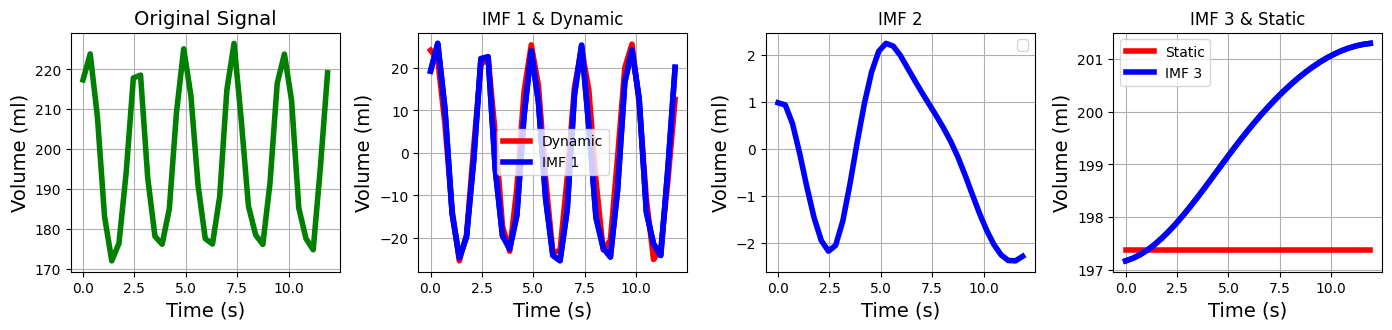

In [13]:
import numpy as np
from scipy import signal
from PyEMD import EMD
import matplotlib.pyplot as plt

# === Your actual data array ===
total_white_points = f[6]   # your signal
sample_rate = 1000 / 350   # Hz

# === Time axis ===
N = len(total_white_points)
duration = N / sample_rate
time_original = np.linspace(0, duration, N, endpoint=False)

# === FFT ===
fft_vals = np.fft.fft(total_white_points)
freqs = np.fft.fftfreq(N, d=1/sample_rate)

# === Bandpass mask (0.2–0.6 Hz) ===
cutoff = 0.0001

low_mask = (np.abs(freqs) <= cutoff)
fft_low = fft_vals * low_mask

# === Inverse FFT ===
signal_lowfiltered = np.real(np.fft.ifft(fft_low))

# === Bandpass mask (0.2–0.6 Hz) ===
lowcut = 0.2
highcut = 0.6

band_mask = (np.abs(freqs) >= lowcut) & (np.abs(freqs) <= highcut)

# Apply mask
fft_filtered = fft_vals * band_mask

# === Inverse FFT ===
signal_filtered1 = np.real(np.fft.ifft(fft_filtered))

# === Step 1: Apply EMD ===

emd = EMD()
imfs = emd(f[6])
num_imfs = imfs.shape[0]
print("Number of IMFs:", num_imfs)

# === FFT ===

freqs = np.fft.fftfreq(N, d=1/sample_rate)

# === Bandpass mask (0.2–0.6 Hz) ===
lowcut = 0.2
highcut = 0.6

band_mask = (np.abs(freqs) >= lowcut) & (np.abs(freqs) <= highcut)

# Apply mask
fft_filtered = fft_vals * band_mask

# # === Inverse FFT ===
# signal_filtered = np.real(np.fft.ifft(fft_filtered))
# === Step 5: Plot original + filtered IMFs ===
plt.figure(figsize=(2.5 * (num_imfs + 4), 12))

# Original Signal
plt.subplot(4, num_imfs + 2, 1)
plt.plot(time_original, total_white_points, 'g', linewidth=4)
plt.title("Original Signal", fontsize=14)
plt.xlabel("Time (s)", fontsize=14)
plt.ylabel("Volume (ml)", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True)

# IMFs (filtered)
for i in range(num_imfs):
    plt.subplot(4, num_imfs + 2, i + 2)
    fft_vals = np.fft.fft(imfs[i])
    signal_filt = fft_vals * band_mask
    signal_filtered = np.real(np.fft.ifft(signal_filt))
    plt.title(f"IMF {i+1}")
    if i == 0:
        plt.plot(time_original, signal_filtered1, label="Dynamic", color='red', linewidth=4)
        plt.title(f"IMF {i+1} & Dynamic")
        plt.plot(time_original, imfs[i], label=f"IMF {i+1}", color='blue', linewidth=4)
    if i == 2:
        plt.plot(time_original, signal_lowfiltered, label="Static", color='red', linewidth=4)
        plt.title(f"IMF {i+1} & Static")
        plt.plot(time_original, imfs[i], label=f"IMF {i+1}", color='blue', linewidth=4)             
    
    # plt.plot(time_original, signal_filtered, label=f"IMF {i+1} Filtered", color='orange')
    plt.plot(time_original, imfs[i], color='blue', linewidth=4)
    plt.legend()
    plt.xlabel("Time (s)", fontsize=14)
    plt.ylabel("Volume (ml)", fontsize=14)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(True)

# Save and show
plt.tight_layout()
plt.savefig("Filtered_IMFs_Above Hz.png", dpi=300, bbox_inches="tight")
plt.show()


Number of IMFs: 4


C:\Users\resea\AppData\Local\Temp\ipykernel_54184\897152457.py:93: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


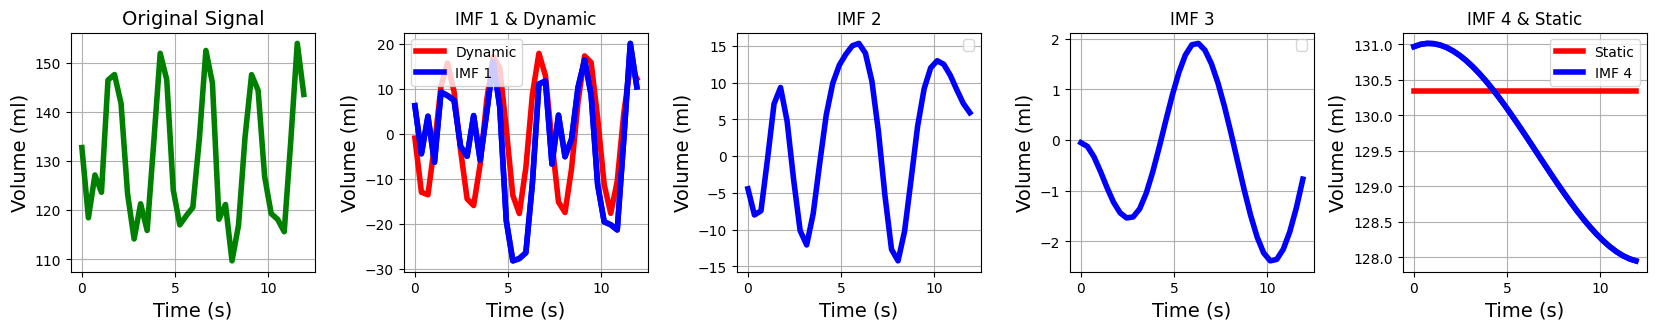

In [16]:
import numpy as np
from scipy import signal
from PyEMD import EMD
import matplotlib.pyplot as plt

# === Your actual data array ===
total_white_points = f[11]   # your signal
sample_rate = 1000 / 350   # Hz

# === Time axis ===
N = len(total_white_points)
duration = N / sample_rate
time_original = np.linspace(0, duration, N, endpoint=False)

# === FFT ===
fft_vals = np.fft.fft(total_white_points)
freqs = np.fft.fftfreq(N, d=1/sample_rate)

# === Bandpass mask (0.2–0.6 Hz) ===
cutoff = 0.0001

low_mask = (np.abs(freqs) <= cutoff)
fft_low = fft_vals * low_mask

# === Inverse FFT ===
signal_lowfiltered = np.real(np.fft.ifft(fft_low))

# === Bandpass mask (0.2–0.6 Hz) ===
lowcut = 0.2
highcut = 0.6

band_mask = (np.abs(freqs) >= lowcut) & (np.abs(freqs) <= highcut)

# Apply mask
fft_filtered = fft_vals * band_mask

# === Inverse FFT ===
signal_filtered1 = np.real(np.fft.ifft(fft_filtered))

# === Step 1: Apply EMD ===

emd = EMD()
imfs = emd(f[11])
num_imfs = imfs.shape[0]
print("Number of IMFs:", num_imfs)

# === FFT ===

freqs = np.fft.fftfreq(N, d=1/sample_rate)

# === Bandpass mask (0.2–0.6 Hz) ===
lowcut = 0.2
highcut = 0.6

band_mask = (np.abs(freqs) >= lowcut) & (np.abs(freqs) <= highcut)

# Apply mask
fft_filtered = fft_vals * band_mask

# # === Inverse FFT ===
# signal_filtered = np.real(np.fft.ifft(fft_filtered))
# === Step 5: Plot original + filtered IMFs ===
plt.figure(figsize=(2.5 * (num_imfs + 4), 12))

# Original Signal
plt.subplot(4, num_imfs + 2, 1)
plt.plot(time_original, total_white_points, 'g', linewidth=4)
plt.title("Original Signal", fontsize=14)
plt.xlabel("Time (s)", fontsize=14)
plt.ylabel("Volume (ml)", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True)

# IMFs (filtered)
for i in range(num_imfs):
    plt.subplot(4, num_imfs + 2, i + 2)
    fft_vals = np.fft.fft(imfs[i])
    signal_filt = fft_vals * band_mask
    signal_filtered = np.real(np.fft.ifft(signal_filt))
    plt.title(f"IMF {i+1}")
    if i == 0:
        plt.plot(time_original, signal_filtered1, label="Dynamic", color='red', linewidth=4)
        plt.title(f"IMF {i+1} & Dynamic")
        plt.plot(time_original, imfs[i], label=f"IMF {i+1}", color='blue', linewidth=4)
    if i == 3:
        plt.plot(time_original, signal_lowfiltered, label="Static", color='red', linewidth=4)
        plt.title(f"IMF {i+1} & Static")
        plt.plot(time_original, imfs[i], label=f"IMF {i+1}", color='blue', linewidth=4)             
    
    # plt.plot(time_original, signal_filtered, label=f"IMF {i+1} Filtered", color='orange')
    plt.plot(time_original, imfs[i], color='blue', linewidth=4)
    plt.legend()
    plt.xlabel("Time (s)", fontsize=14)
    plt.ylabel("Volume (ml)", fontsize=14)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(True)

# Save and show
plt.tight_layout()
plt.savefig("Filtered_IMFs_Above Hz.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
import numpy as np
from scipy import signal
from PyEMD import EMD
import matplotlib.pyplot as plt

# === Your actual data array ===
total_white_points = f[8]   # your signal
sample_rate = 1000 / 350   # Hz

# === Time axis ===
N = len(total_white_points)
duration = N / sample_rate
time_original = np.linspace(0, duration, N, endpoint=False)

# === FFT ===
fft_vals = np.fft.fft(total_white_points)
freqs = np.fft.fftfreq(N, d=1/sample_rate)

# === Bandpass mask (0.2–0.6 Hz) ===
cutoff = 0.0001

low_mask = (np.abs(freqs) <= cutoff)
fft_low = fft_vals * low_mask

# === Inverse FFT ===
signal_lowfiltered = np.real(np.fft.ifft(fft_low))

# === Bandpass mask (0.2–0.6 Hz) ===
lowcut = 0.2
highcut = 0.6

band_mask = (np.abs(freqs) >= lowcut) & (np.abs(freqs) <= highcut)

# Apply mask
fft_filtered = fft_vals * band_mask

# === Inverse FFT ===
signal_filtered1 = np.real(np.fft.ifft(fft_filtered))

# === Step 1: Apply EMD ===

emd = EMD()
imfs = emd(f[8])
num_imfs = imfs.shape[0]
print("Number of IMFs:", num_imfs)

# === FFT ===

freqs = np.fft.fftfreq(N, d=1/sample_rate)

# === Bandpass mask (0.2–0.6 Hz) ===
lowcut = 0.2
highcut = 0.6

band_mask = (np.abs(freqs) >= lowcut) & (np.abs(freqs) <= highcut)

# Apply mask
fft_filtered = fft_vals * band_mask

# # === Inverse FFT ===
# signal_filtered = np.real(np.fft.ifft(fft_filtered))
# === Step 5: Plot original + filtered IMFs ===
plt.figure(figsize=(2.5 * (num_imfs + 4), 12))

# Original Signal
plt.subplot(4, num_imfs + 2, 1)
plt.plot(time_original, total_white_points, 'g')
plt.title("Original Signal")
plt.xlabel("Time (s)")
plt.ylabel("Volume (ml)")
plt.grid(True)

# IMFs (filtered)
for i in range(num_imfs):
    plt.subplot(4, num_imfs + 2, i + 2)
    fft_vals = np.fft.fft(imfs[i])
    signal_filt = fft_vals * band_mask
    signal_filtered = np.real(np.fft.ifft(signal_filt))
    plt.title(f"IMF {i+1}")
    if i == 0:
        plt.plot(time_original, signal_filtered1, label="Dynamic", color='red')
        plt.title(f"IMF {i+1} & Dynamic")
    if i == 2:
        plt.plot(time_original, signal_lowfiltered, label="Static", color='red')
        plt.title(f"IMF {i+1} & Static")             
    
    # plt.plot(time_original, signal_filtered, label=f"IMF {i+1} Filtered", color='orange')
    plt.plot(time_original, imfs[i], label=f"IMF {i+1}", color='blue')
    plt.legend()
    plt.xlabel("Time (s)")
    plt.ylabel("Volume (ml)")
    plt.grid(True)

# Save and show
plt.tight_layout()
plt.savefig("Filtered_IMFs_Above_0.2Hz - 0.6 Hz.pdf", format="pdf", bbox_inches="tight")
plt.show()


Number of IMFs: 3


C:\Users\resea\AppData\Local\Temp\ipykernel_54184\1552885949.py:91: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


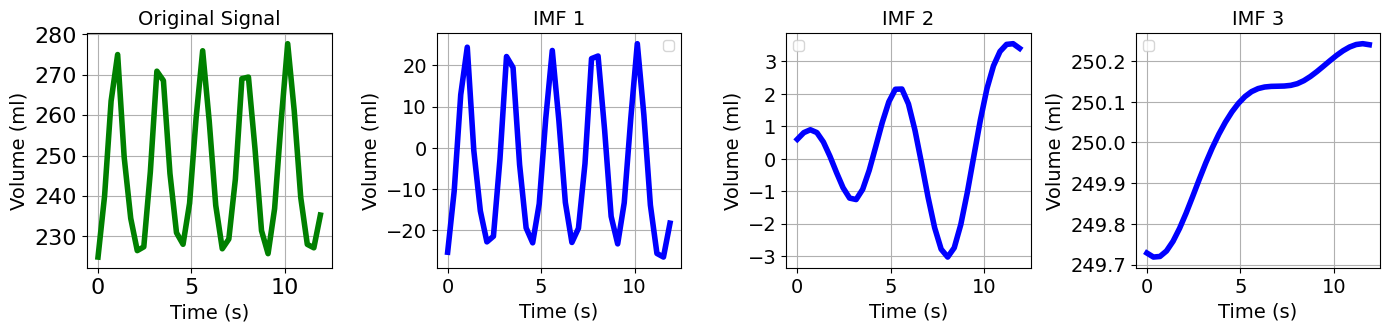

In [3]:
import numpy as np
from scipy import signal
from PyEMD import EMD
import matplotlib.pyplot as plt

# === Your actual data array ===
total_white_points = f[8]   # your signal
sample_rate = 1000 / 350   # Hz

# === Time axis ===
N = len(total_white_points)
duration = N / sample_rate
time_original = np.linspace(0, duration, N, endpoint=False)

# === FFT ===
fft_vals = np.fft.fft(total_white_points)
freqs = np.fft.fftfreq(N, d=1/sample_rate)

# === Bandpass mask (0.2–0.6 Hz) ===
cutoff = 0.0001

low_mask = (np.abs(freqs) <= cutoff)
fft_low = fft_vals * low_mask

# === Inverse FFT ===
signal_lowfiltered = np.real(np.fft.ifft(fft_low))

# === Bandpass mask (0.2–0.6 Hz) ===
lowcut = 0.2
highcut = 0.6

band_mask = (np.abs(freqs) >= lowcut) & (np.abs(freqs) <= highcut)

# Apply mask
fft_filtered = fft_vals * band_mask

# === Inverse FFT ===
signal_filtered1 = np.real(np.fft.ifft(fft_filtered))

# === Step 1: Apply EMD ===

emd = EMD()
imfs = emd(f[8])
num_imfs = imfs.shape[0]
print("Number of IMFs:", num_imfs)

# === FFT ===

freqs = np.fft.fftfreq(N, d=1/sample_rate)

# === Bandpass mask (0.2–0.6 Hz) ===
lowcut = 0.2
highcut = 0.6

band_mask = (np.abs(freqs) >= lowcut) & (np.abs(freqs) <= highcut)

# Apply mask
fft_filtered = fft_vals * band_mask

# # === Inverse FFT ===
# signal_filtered = np.real(np.fft.ifft(fft_filtered))
# === Step 5: Plot original + filtered IMFs ===
plt.figure(figsize=(2.5 * (num_imfs + 4), 12))

# Original Signal
plt.subplot(4, num_imfs + 2, 1)
plt.plot(time_original, total_white_points, 'g', linewidth =4)
plt.title("Original Signal",fontsize=14)
plt.xlabel("Time (s)", fontsize=14)
plt.ylabel("Volume (ml)", fontsize=14)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True)

# IMFs (filtered)
for i in range(num_imfs):
    plt.subplot(4, num_imfs + 2, i + 2)
    fft_vals = np.fft.fft(imfs[i])
    signal_filt = fft_vals * band_mask
    signal_filtered = np.real(np.fft.ifft(signal_filt))
    plt.title(f"IMF {i+1}", fontsize=14)
    # if i == 0:
    #     plt.plot(time_original, signal_filtered1, label="Dynamic", color='red')
    #     plt.title(f"IMF {i+1} & Dynamic")
    # if i == 2:
    #     plt.plot(time_original, signal_lowfiltered, label="Static", color='red')
    #     plt.title(f"IMF {i+1} & Static")             
    
    # plt.plot(time_original, signal_filtered, label=f"IMF {i+1} Filtered", color='orange')
    plt.plot(time_original, imfs[i], color='blue', linewidth=4)
    plt.legend()
    plt.xlabel("Time (s)", fontsize=14)
    plt.ylabel("Volume (ml)", fontsize=14)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.grid(True)

# Save and show
plt.tight_layout()
plt.savefig("EMD.png", dpi=400, bbox_inches="tight")
plt.show()


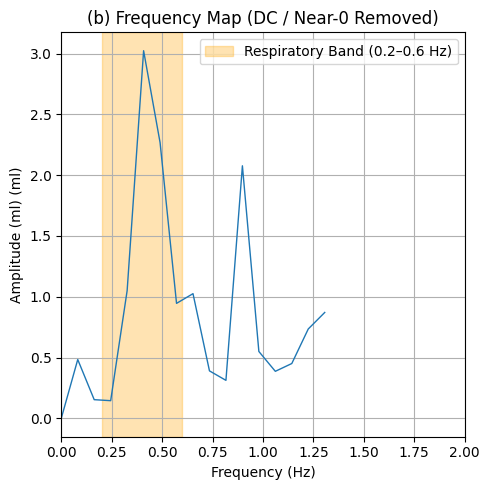

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# === Signal ===
# signal = np.fft.fft(imfs[1])
signal = f[18]
fs = 1000 / 350  # Hz
N = len(signal)

# === FFT ===
fft_vals = np.fft.fft(signal)
freqs = np.fft.fftfreq(N, d=1/fs)

# === Remove frequencies close to 0 Hz ===
low_freq_cutoff = 0.00001  # Hz (adjust: 0.03–0.1 typical for respiration)
mask = np.abs(freqs) >= low_freq_cutoff

fft_cleaned = fft_vals * mask

# === Magnitude spectrum (positive frequencies only) ===
positive_freqs = freqs[:N//2]
magnitude = np.abs(fft_cleaned[:N//2]) / N

# === Plot frequency map ===
plt.figure(figsize=(5, 5))
plt.plot(positive_freqs, magnitude, linewidth=1)

plt.axvspan(0.2, 0.6, color='orange', alpha=0.3,
            label='Respiratory Band (0.2–0.6 Hz)')

plt.title("(b) Frequency Map (DC / Near-0 Removed)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude (ml) (ml)")
plt.xlim(0, 2)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig("Frequency_Map_No_DC.pdf", bbox_inches="tight")
plt.show()


Number of IMFs: 0


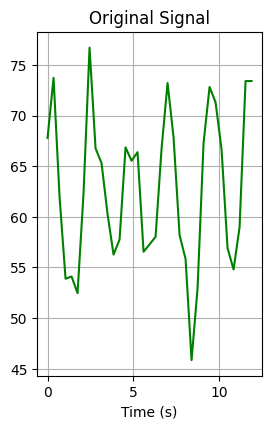

In [19]:
import numpy as np
from scipy import signal
from PyEMD import EMD
import matplotlib.pyplot as plt

# === Your actual data array ===
total_white_points = f[12]   # your signal
sample_rate = 1000 / 350   # Hz

# === Time axis ===
N = len(total_white_points)
duration = N / sample_rate
time_original = np.linspace(0, duration, N, endpoint=False)

# === FFT ===
fft_vals = np.fft.fft(total_white_points)
freqs = np.fft.fftfreq(N, d=1/sample_rate)

# === Bandpass mask (0.2–0.6 Hz) ===
cutoff = 0.0001

low_mask = (np.abs(freqs) <= cutoff)
fft_low = fft_vals * low_mask

# === Inverse FFT ===
signal_lowfiltered = np.real(np.fft.ifft(fft_low))

# === Bandpass mask (0.2–0.6 Hz) ===
lowcut = 0.2
highcut = 0.6

band_mask = (np.abs(freqs) >= lowcut) & (np.abs(freqs) <= highcut)

# Apply mask
fft_filtered = fft_vals * band_mask

# === Inverse FFT ===
signal_filtered1 = np.real(np.fft.ifft(fft_filtered))

# === Step 1: Apply EMD ===

emd = EMD()
imfs = emd(f[13])
num_imfs = imfs.shape[0]
print("Number of IMFs:", num_imfs)

# === FFT ===

freqs = np.fft.fftfreq(N, d=1/sample_rate)

# === Bandpass mask (0.2–0.6 Hz) ===
lowcut = 0.2
highcut = 0.6

band_mask = (np.abs(freqs) >= lowcut) & (np.abs(freqs) <= highcut)

# Apply mask
fft_filtered = fft_vals * band_mask

# # === Inverse FFT ===
# signal_filtered = np.real(np.fft.ifft(fft_filtered))





# === Step 5: Plot original + filtered IMFs ===
plt.figure(figsize=(2.5 * (num_imfs + 4), 12))

# Original Signal
plt.subplot(3, num_imfs + 4, 1)
plt.plot(time_original, total_white_points, 'g')
plt.title("Original Signal")
plt.xlabel("Time (s)")
plt.grid(True)

# IMFs (filtered)
for i in range(num_imfs):
    plt.subplot(3, num_imfs + 2, i + 2)
    fft_vals = np.fft.fft(imfs[i])
    signal_filt = fft_vals * band_mask
    signal_filtered = np.real(np.fft.ifft(signal_filt))
    if i == 0:
        plt.plot(time_original, signal_filtered1, 'red')
    if i == 2:
        plt.plot(time_original, signal_lowfiltered, 'red')        
    
    plt.plot(time_original, signal_filtered, label=f"IMF {i+1} Filtered", color='orange')
    plt.plot(time_original, imfs[i], label=f"IMF {i+1}", color='blue')
    plt.legend()
    plt.xlabel("Time (s)")
    plt.grid(True)

# Save and show
plt.tight_layout()
plt.savefig("Filtered_IMFs_Above_0.2Hz - 0.6 Hz.pdf", format="pdf", bbox_inches="tight")
plt.show()


Number of IMFs: 3


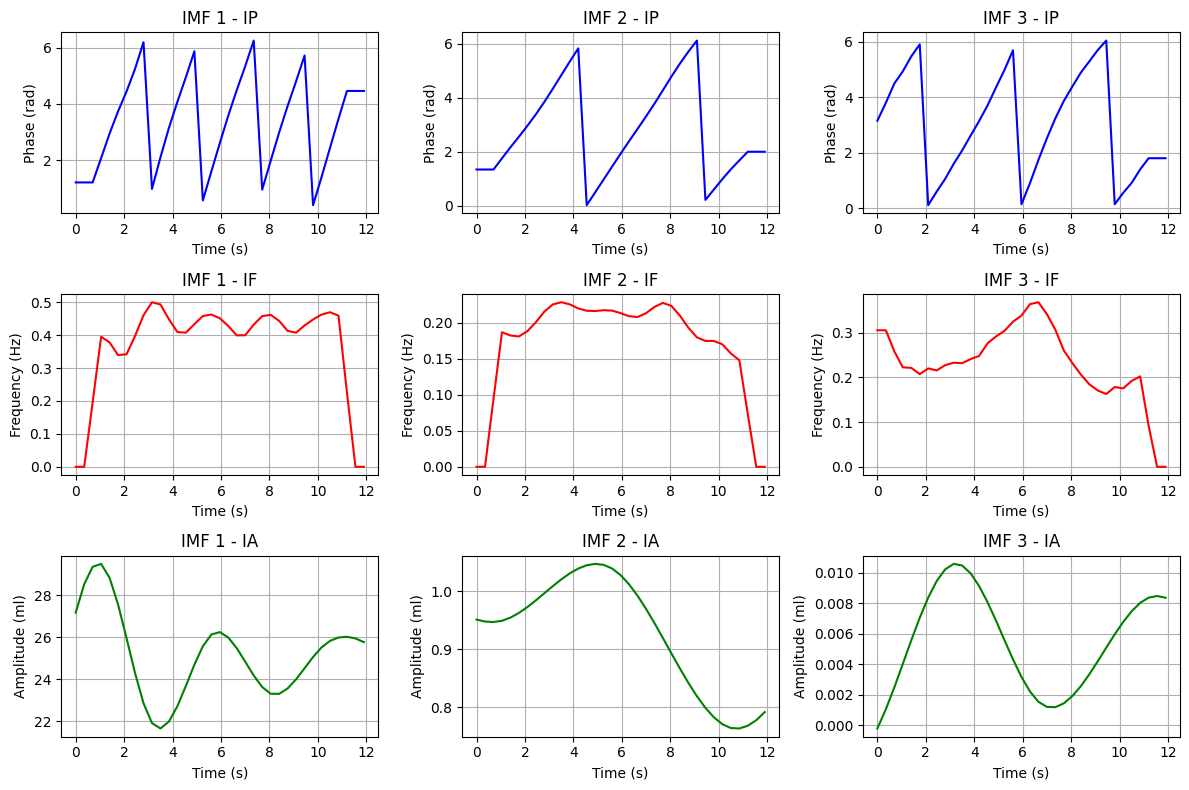

=== Processing slice: 0 ===
Number of IMFs: 0
static: 0
Slice 0: Sum of Avg Amplitudes = 0.0000
=== Processing slice: 1 ===
Number of IMFs: 0
static: 0
Slice 1: Sum of Avg Amplitudes = 0.0000
=== Processing slice: 2 ===
Number of IMFs: 3
static: 76.68937673330454
Slice 2: Sum of Avg Amplitudes = 9.4922
=== Processing slice: 3 ===
Number of IMFs: 4
static: 136.54002801553793
Slice 3: Sum of Avg Amplitudes = 24.2485
=== Processing slice: 4 ===
Number of IMFs: 3
static: 159.31090072556668
Slice 4: Sum of Avg Amplitudes = 25.7827
=== Processing slice: 5 ===
Number of IMFs: 3
static: 170.35574728005088
Slice 5: Sum of Avg Amplitudes = 25.1234
=== Processing slice: 6 ===
Number of IMFs: 3
static: 199.44440482734342
Slice 6: Sum of Avg Amplitudes = 27.0250
=== Processing slice: 7 ===
Number of IMFs: 3
static: 230.59877269907594
Slice 7: Sum of Avg Amplitudes = 26.3764
=== Processing slice: 8 ===
Number of IMFs: 3
static: 250.0486713997724
Slice 8: Sum of Avg Amplitudes = 26.1245
=== Processin

In [20]:
import numpy as np
from scipy import signal
from PyEMD import EMD
import matplotlib.pyplot as plt
import emd  # Install with: pip install EMD-signal

# === Replace with your actual signal ===
total_white_points = f[8]  # NumPy array
sample_rate = 1000/350  # Hz

# Time axis
duration = len(total_white_points) / sample_rate
time = np.linspace(0, duration, len(total_white_points), endpoint=False)

# === Step 1: EMD decomposition ===
emd_decomposer = EMD()
imfs = emd_decomposer(total_white_points)
num_imfs = imfs.shape[0]
print(f"Number of IMFs: {num_imfs}")

def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = 0.5*fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = signal.butter(order, [low, high], btype='band', analog=False)
    return b, a

def apply_bandpass(data, lowcut, highcut, fs, order=4):
    b, a = butter_bandpass(lowcut, highcut, fs, order)
    return signal.filtfilt(b, a, data)

# === Apply bandpass filter to each IMF ===
lowcut_hz = 0.2  # Lower cutoff frequency (Hz)
highcut_hz = 0.9  # Upper cutoff frequency (Hz)

filtered_imfs = []
for i in range(num_imfs):
    filtered = apply_bandpass(imfs[i], lowcut=lowcut_hz, highcut=highcut_hz, fs=sample_rate)
    filtered_imfs.append(filtered)
filtered_imfs = np.array(filtered_imfs)

# === Step 3: Analyze IP, IF, IA using Hilbert transform ===
IPs, IFs, IAs = [], [], []
for i in range(num_imfs):
    ip, freq, amp = emd.spectra.frequency_transform(filtered_imfs[i], sample_rate, method='nht')
    IPs.append(ip)
    IFs.append(freq)
    IAs.append(amp)

IPs, IFs, IAs = np.array(IPs), np.array(IFs), np.array(IAs)

# === Step 4: Plot IP, IF, IA for first 5 IMFs ===
plot_imfs = min(5, num_imfs)  # Limit to 5 IMFs
fig, axes = plt.subplots(3, plot_imfs, figsize=(4 * plot_imfs, 8))

for i in range(plot_imfs):
    axes[0, i].plot(time, IPs[i], label=f'IMF {i+1} - Phase', color='blue')
    axes[0, i].set_title(f'IMF {i+1} - IP')
    axes[0, i].set_xlabel("Time (s)")
    axes[0, i].set_ylabel("Phase (rad)")
    axes[0, i].grid(True)

    axes[1, i].plot(time, IFs[i], label=f'IMF {i+1} - Frequency', color='red')
    axes[1, i].set_title(f'IMF {i+1} - IF')
    axes[1, i].set_xlabel("Time (s)")
    axes[1, i].set_ylabel("Frequency (Hz)")
    axes[1, i].grid(True)

    axes[2, i].plot(time, IAs[i], label=f'IMF {i+1} - Amplitude', color='green')
    axes[2, i].set_title(f'IMF {i+1} - IA')
    axes[2, i].set_xlabel("Time (s)")
    axes[2, i].set_ylabel("Amplitude (ml)")
    axes[2, i].grid(True)

plt.tight_layout()
plt.savefig("Filtered_IMFs_IP_IF_IA.pdf", format="pdf", bbox_inches="tight")
plt.show()
slice_sums = []  # Store sum of average amplitudes per slice
static_sum = []
for slice_idx in range(len(f)):
    print(f"=== Processing slice: {slice_idx} ===")
    
    emd_decomposer = EMD()
    imfs = emd_decomposer(f[slice_idx])
    num_imfs = imfs.shape[0]
    print(f"Number of IMFs: {num_imfs}")
    if num_imfs == 0:
        avg_amplitudes = np.mean(0)
        std_amplitudes = np.mean(0)
        slice_sum = 0
        avg_static = 0
        static_sum.append(0)
        print(f"static: {avg_static}")
    else:
        avg_static = np.mean(imfs[num_imfs-1])
        print(f"static: {avg_static}")
        static_sum.append(avg_static)
        filtered_imfs = []
        for i in range(num_imfs):
            filtered = apply_bandpass(imfs[i], lowcut=lowcut_hz, highcut=highcut_hz, fs=sample_rate)
            filtered_imfs.append(filtered)
        filtered_imfs = np.array(filtered_imfs)

        IPs, IFs, IAs = [], [], []
        for i in range(num_imfs):
            ip, freq, amp = emd.spectra.frequency_transform(filtered_imfs[i], sample_rate, method='nht')
            IPs.append(ip)
            IFs.append(freq)
            IAs.append(amp)
        IAs = np.array(IAs)

        avg_amplitudes = np.mean(IAs, axis=1)
        std_amplitudes = np.std(IAs, axis=1)
        # Sum of average amplitudes for this slice
        slice_sum = np.sum(avg_amplitudes)
    print(f"Slice {slice_idx}: Sum of Avg Amplitudes = {slice_sum:.4f}")
    slice_sums.append(slice_sum)

    # for i, (avg, std) in enumerate(zip(avg_amplitudes, std_amplitudes)):
    #     print(f"IMF {i+1}: Avg Amplitude = {float(avg):.4f}, Std Dev = {float(std):.4f}")
    # print(f"Slice {slice_idx}: Sum of Avg Amplitudes = {slice_sum:.4f}")

# === Final Summary ===
slice_sums = np.array(slice_sums)
total_of_averages = np.sum(slice_sums)
static = np.sum(static_sum)

print(f"\n=== Final Results ===")
print(f"Sum of all average amplitudes (across all slices): {total_of_averages:.4f}")
print(f"Standard deviation of per-slice sums: {float(static):.4f}")



In [21]:
slice_sums = []  # Store sum of average amplitudes per slice
static_sum = []
for slice_idx in range(len(f)):
    print(f"=== Processing slice: {slice_idx} ===")
    
    emd_decomposer = EMD()
    imfs = emd_decomposer(f[slice_idx])
    num_imfs = imfs.shape[0]
    print(f"Number of IMFs: {num_imfs}")
    if num_imfs == 0:
        avg_amplitudes = np.mean(0)
        std_amplitudes = np.mean(0)
        slice_sum = 0
        avg_static = 0
        static_sum.append(0)
        print(f"static: {avg_static}")
    else:
        avg_static = np.mean(imfs[num_imfs-1])
        print(f"static: {avg_static}")
        static_sum.append(avg_static)
        filtered_imfs = []
        for i in range(num_imfs):
            filtered = apply_bandpass(imfs[i], lowcut=lowcut_hz, highcut=highcut_hz, fs=sample_rate)
            filtered_imfs.append(filtered)
        filtered_imfs = np.array(filtered_imfs)

        IPs, IFs, IAs = [], [], []
        for i in range(num_imfs):
            ip, freq, amp = emd.spectra.frequency_transform(filtered_imfs[i], sample_rate, method='nht')
            IPs.append(ip)
            IFs.append(freq)
            IAs.append(amp)
        IAs = np.array(IAs)

        avg_amplitudes = np.mean(IAs, axis=1)
        std_amplitudes = np.std(IAs, axis=1)
        # Sum of average amplitudes for this slice
        slice_sum = np.sum(avg_amplitudes)
    print(f"Slice {slice_idx}: Sum of Avg Amplitudes = {slice_sum:.4f}")
    slice_sums.append(slice_sum)

    # for i, (avg, std) in enumerate(zip(avg_amplitudes, std_amplitudes)):
    #     print(f"IMF {i+1}: Avg Amplitude = {float(avg):.4f}, Std Dev = {float(std):.4f}")
    # print(f"Slice {slice_idx}: Sum of Avg Amplitudes = {slice_sum:.4f}")

# === Final Summary ===
slice_sums = np.array(slice_sums)
total_of_averages = np.sum(slice_sums)
static = np.sum(static_sum)

print(f"\n=== Final Results ===")
print(f"Sum of all average amplitudes (across all slices): {total_of_averages:.4f}")
print(f"Standard deviation of per-slice sums: {float(static):.4f}")


=== Processing slice: 0 ===
Number of IMFs: 0
static: 0
Slice 0: Sum of Avg Amplitudes = 0.0000
=== Processing slice: 1 ===
Number of IMFs: 0
static: 0
Slice 1: Sum of Avg Amplitudes = 0.0000
=== Processing slice: 2 ===
Number of IMFs: 3
static: 76.68937673330454
Slice 2: Sum of Avg Amplitudes = 9.4922
=== Processing slice: 3 ===
Number of IMFs: 4
static: 136.54002801553793
Slice 3: Sum of Avg Amplitudes = 24.2485
=== Processing slice: 4 ===
Number of IMFs: 3
static: 159.31090072556668
Slice 4: Sum of Avg Amplitudes = 25.7827
=== Processing slice: 5 ===
Number of IMFs: 3
static: 170.35574728005088
Slice 5: Sum of Avg Amplitudes = 25.1234
=== Processing slice: 6 ===
Number of IMFs: 3
static: 199.44440482734342
Slice 6: Sum of Avg Amplitudes = 27.0250
=== Processing slice: 7 ===
Number of IMFs: 3
static: 230.59877269907594
Slice 7: Sum of Avg Amplitudes = 26.3764
=== Processing slice: 8 ===
Number of IMFs: 3
static: 250.0486713997724
Slice 8: Sum of Avg Amplitudes = 26.1245
=== Processin

Number of IMFs: 3


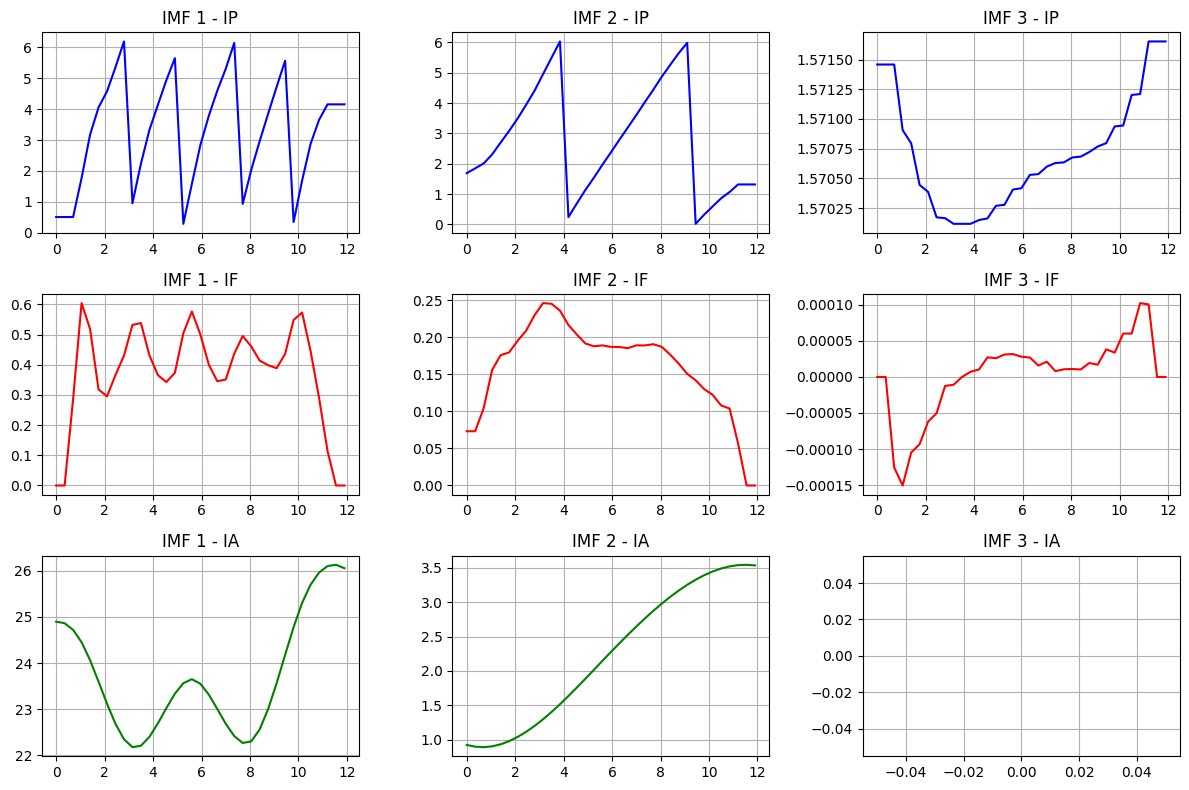


=== Processing slice: 0 ===
Number of IMFs: 0

=== Processing slice: 1 ===
Number of IMFs: 0

=== Processing slice: 2 ===
Number of IMFs: 3
Static (last IMF mean): 76.6894

=== Processing slice: 3 ===
Number of IMFs: 4
Static (last IMF mean): 136.5400

=== Processing slice: 4 ===
Number of IMFs: 3
Static (last IMF mean): 159.3109

=== Processing slice: 5 ===
Number of IMFs: 3
Static (last IMF mean): 170.3557

=== Processing slice: 6 ===
Number of IMFs: 3
Static (last IMF mean): 199.4444

=== Processing slice: 7 ===
Number of IMFs: 3
Static (last IMF mean): 230.5988

=== Processing slice: 8 ===
Number of IMFs: 3
Static (last IMF mean): 250.0487

=== Processing slice: 9 ===
Number of IMFs: 4
Static (last IMF mean): 229.7477

=== Processing slice: 10 ===
Number of IMFs: 3
Static (last IMF mean): 205.7535

=== Processing slice: 11 ===
Number of IMFs: 4
Static (last IMF mean): 129.6322

=== Processing slice: 12 ===
Number of IMFs: 4
Static (last IMF mean): 62.2386

=== Processing slice: 13

C:\Users\resea\AppData\Local\Temp\ipykernel_45716\835111256.py:114: RuntimeWarning: Mean of empty slice
  avg_amplitudes = np.nanmean(IAs, axis=1)


In [22]:
import numpy as np
from scipy import signal
from PyEMD import EMD
import matplotlib.pyplot as plt
import emd  # pip install EMD-signal

# =========================
# INPUT
# =========================
sample_rate = 1000 / 350  # Hz

# Example signal
total_white_points = f[8]

time = np.linspace(
    0,
    len(total_white_points) / sample_rate,
    len(total_white_points),
    endpoint=False
)

# =========================
# STEP 1: EMD (single signal demo)
# =========================
emd_decomposer = EMD()
imfs = emd_decomposer(total_white_points)
num_imfs = imfs.shape[0]
print(f"Number of IMFs: {num_imfs}")

# =========================
# STEP 2: Hilbert spectral analysis (NO filtering)
# =========================
IPs, IFs, IAs = [], [], []

for i in range(num_imfs):
    ip, freq, amp = emd.spectra.frequency_transform(
        imfs[i],
        sample_rate,
        method='nht'
    )
    IPs.append(ip)
    IFs.append(freq)
    IAs.append(amp)

IPs = np.array(IPs)
IFs = np.array(IFs)
IAs = np.array(IAs)

# =========================
# STEP 3: Plot IP, IF, IA (first 5 IMFs)
# =========================
plot_imfs = min(5, num_imfs)
fig, axes = plt.subplots(3, plot_imfs, figsize=(4 * plot_imfs, 8))

for i in range(plot_imfs):
    axes[0, i].plot(time, IPs[i], color='blue')
    axes[0, i].set_title(f'IMF {i+1} - IP')
    axes[0, i].grid(True)

    axes[1, i].plot(time, IFs[i], color='red')
    axes[1, i].set_title(f'IMF {i+1} - IF')
    axes[1, i].grid(True)

    axes[2, i].plot(time, IAs[i], color='green')
    axes[2, i].set_title(f'IMF {i+1} - IA')
    axes[2, i].grid(True)

plt.tight_layout()
plt.savefig("IMFs_IP_IF_IA_NoBandpass.pdf", bbox_inches="tight")
plt.show()

# =========================
# SLICE-WISE ANALYSIS (f[0] → f[N])
# =========================
slice_sums = []
static_sum = []

for slice_idx in range(len(f)):
    print(f"\n=== Processing slice: {slice_idx} ===")

    emd_decomposer = EMD()
    imfs = emd_decomposer(f[slice_idx])
    num_imfs = imfs.shape[0]
    print(f"Number of IMFs: {num_imfs}")

    if num_imfs == 0:
        slice_sums.append(0)
        static_sum.append(0)
        continue

    # ---- Static component (last IMF) ----
    static_component = np.mean(imfs[-1])
    static_sum.append(static_component)
    print(f"Static (last IMF mean): {static_component:.4f}")

    # ---- Hilbert analysis on raw IMFs ----
IAs = []

for i in range(num_imfs):
    _, _, amp = emd.spectra.frequency_transform(
        imfs[i],
        sample_rate,
        method='nht'
    )

    # Convert to float array explicitly
    amp = np.asarray(amp, dtype=float)

    IAs.append(amp)

IAs = np.array(IAs)

# --- Robust statistics (IGNORE NaNs) ---
avg_amplitudes = np.nanmean(IAs, axis=1)
slice_sum = np.nansum(avg_amplitudes)

slice_sums.append(slice_sum)

print(f"Slice {slice_idx}: Sum of Avg Amplitudes = {slice_sum:.4f}")


# =========================
# FINAL SUMMARY
# =========================
slice_sums = np.array(slice_sums)
static_sum = np.array(static_sum)

print("\n=== FINAL RESULTS ===")
print(f"Sum of all slice average amplitudes: {np.sum(slice_sums):.4f}")
print(f"Sum of static components: {np.sum(static_sum):.4f}")


In [23]:
import pandas as pd

# === Final Summary ===
slice_sums = np.array(slice_sums)
static_sum = np.array(static_sum)
total_of_averages = np.sum(slice_sums)
std_of_slice_sums = np.std(slice_sums)
total_static = np.sum(static_sum)
std_static = np.std(static_sum)

print(f"\n=== Final Results ===")
print(f"Sum of all average amplitudes (across all slices): {total_of_averages:.4f}")
print(f"Standard deviation of per-slice sums: {std_of_slice_sums:.4f}")
print(f"Sum of static components: {total_static:.4f}")

# === Export to CSV ===
results_df = pd.DataFrame({
    'Slice Index': np.arange(len(slice_sums)),
    'Static (IMF_last Mean)': static_sum,
    'Amplitude Sum': slice_sums
})

csv_filename = "slice_static_amplitude_summary.csv"
results_df.to_csv(csv_filename, index=False)
print(f"\nResults exported to: {csv_filename}")



=== Final Results ===
Sum of all average amplitudes (across all slices): 3.0479
Standard deviation of per-slice sums: 1.0665
Sum of static components: 3044.1292


ValueError: All arrays must be of the same length

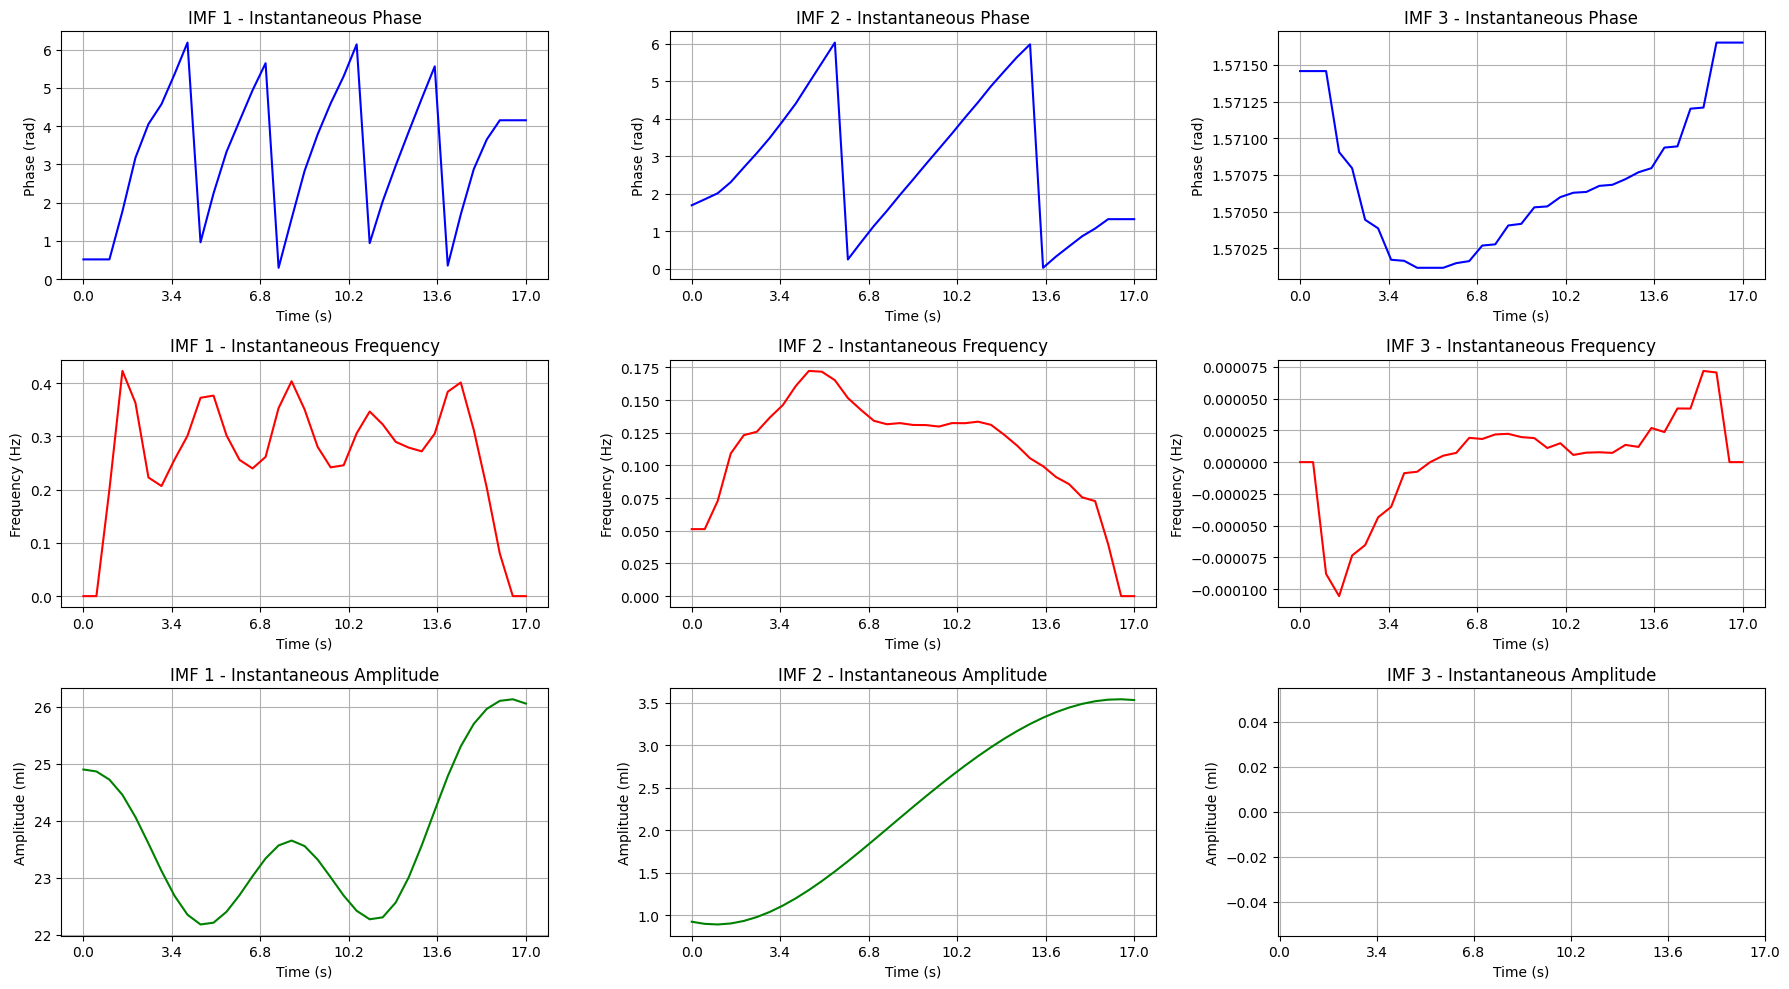

In [66]:
import numpy as np
import emd
import matplotlib.pyplot as plt

# Example signal (replace with your actual data)
imf = f

# Step 2: Define a function to apply frequency_transform to each IMF
def analyze_imf(imf, sample_rate):
    """
    Analyzes the IMF using frequency transform to get IP, IF, and IA.
    """
    IP, IF, IA = emd.spectra.frequency_transform(imf, sample_rate, 'nht')
    return IP, IF, IA

# Step 3: Set the sample rate
sample_rate = 2  # Set your sample rate

# Step 4: Analyze each IMF and extract the Instantaneous Phase (IP), Frequency (IF), and Amplitude (IA)
IPs, IFs, IAs = [], [], []
for i in range(num_imfs):
    IP, IF, IA = analyze_imf(imfs[i], sample_rate)
    IPs.append(IP)
    IFs.append(IF)
    IAs.append(IA)

# Convert the results to numpy arrays for easier plotting
IPs = np.array(IPs)
IFs = np.array(IFs)
IAs = np.array(IAs)

import numpy as np
import matplotlib.pyplot as plt

# Assume: time, IPs, IFs, IAs are already defined
num_to_plot = min(3, len(IPs))
time = np.linspace(0, len(IPs[0]) / sample_rate, len(IPs[0]), endpoint=False)

# Generate consistent tick positions and labels
num_ticks = 6  # Change as needed
tick_positions = np.linspace(time[0], time[-1], num_ticks)
tick_labels = [f"{x:.1f}" for x in tick_positions]

# Create subplots
fig, axes = plt.subplots(3, 3, figsize=(6 * num_to_plot, 10), sharex=False)

for i in range(num_to_plot):
    # IMF i - Instantaneous Phase
    axes[0, i].plot(time, IPs[i], color='b')
    axes[0, i].set_title(f"IMF {i+1} - Instantaneous Phase")
    axes[0, i].set_ylabel("Phase (rad)")
    axes[0, i].set_xticks(tick_positions)
    axes[0, i].set_xticklabels(tick_labels)
    axes[0, i].set_xlabel("Time (s)")
    axes[0, i].grid(True)

    # IMF i - Instantaneous Frequency
    axes[1, i].plot(time, IFs[i], color='r')
    axes[1, i].set_title(f"IMF {i+1} - Instantaneous Frequency")
    axes[1, i].set_ylabel("Frequency (Hz)")
    axes[1, i].set_xticks(tick_positions)
    axes[1, i].set_xticklabels(tick_labels)
    axes[1, i].set_xlabel("Time (s)")
    axes[1, i].grid(True)

    # IMF i - Instantaneous Amplitude
    axes[2, i].plot(time, IAs[i], color='g')
    axes[2, i].set_title(f"IMF {i+1} - Instantaneous Amplitude")
    axes[2, i].set_ylabel("Amplitude (ml)")
    axes[2, i].set_xticks(tick_positions)
    axes[2, i].set_xticklabels(tick_labels)
    axes[2, i].set_xlabel("Time (s)")
    axes[2, i].grid(True)

plt.tight_layout()
plt.savefig("imf_3x3_with_time_ticks.pdf", format="pdf", bbox_inches="tight")
plt.show()


In [ ]:
# === Calculate IP, IF, IA of original IMFs ===
orig_IPs, orig_IFs, orig_IAs = [], [], []
for i in range(num_imfs):
    ip, freq, amp = emd.spectra.frequency_transform(imfs[i], sample_rate, method='nht')
    orig_IPs.append(ip)
    orig_IFs.append(freq)
    orig_IAs.append(amp)

orig_IPs = np.array(orig_IPs)
orig_IFs = np.array(orig_IFs)
orig_IAs = np.array(orig_IAs)


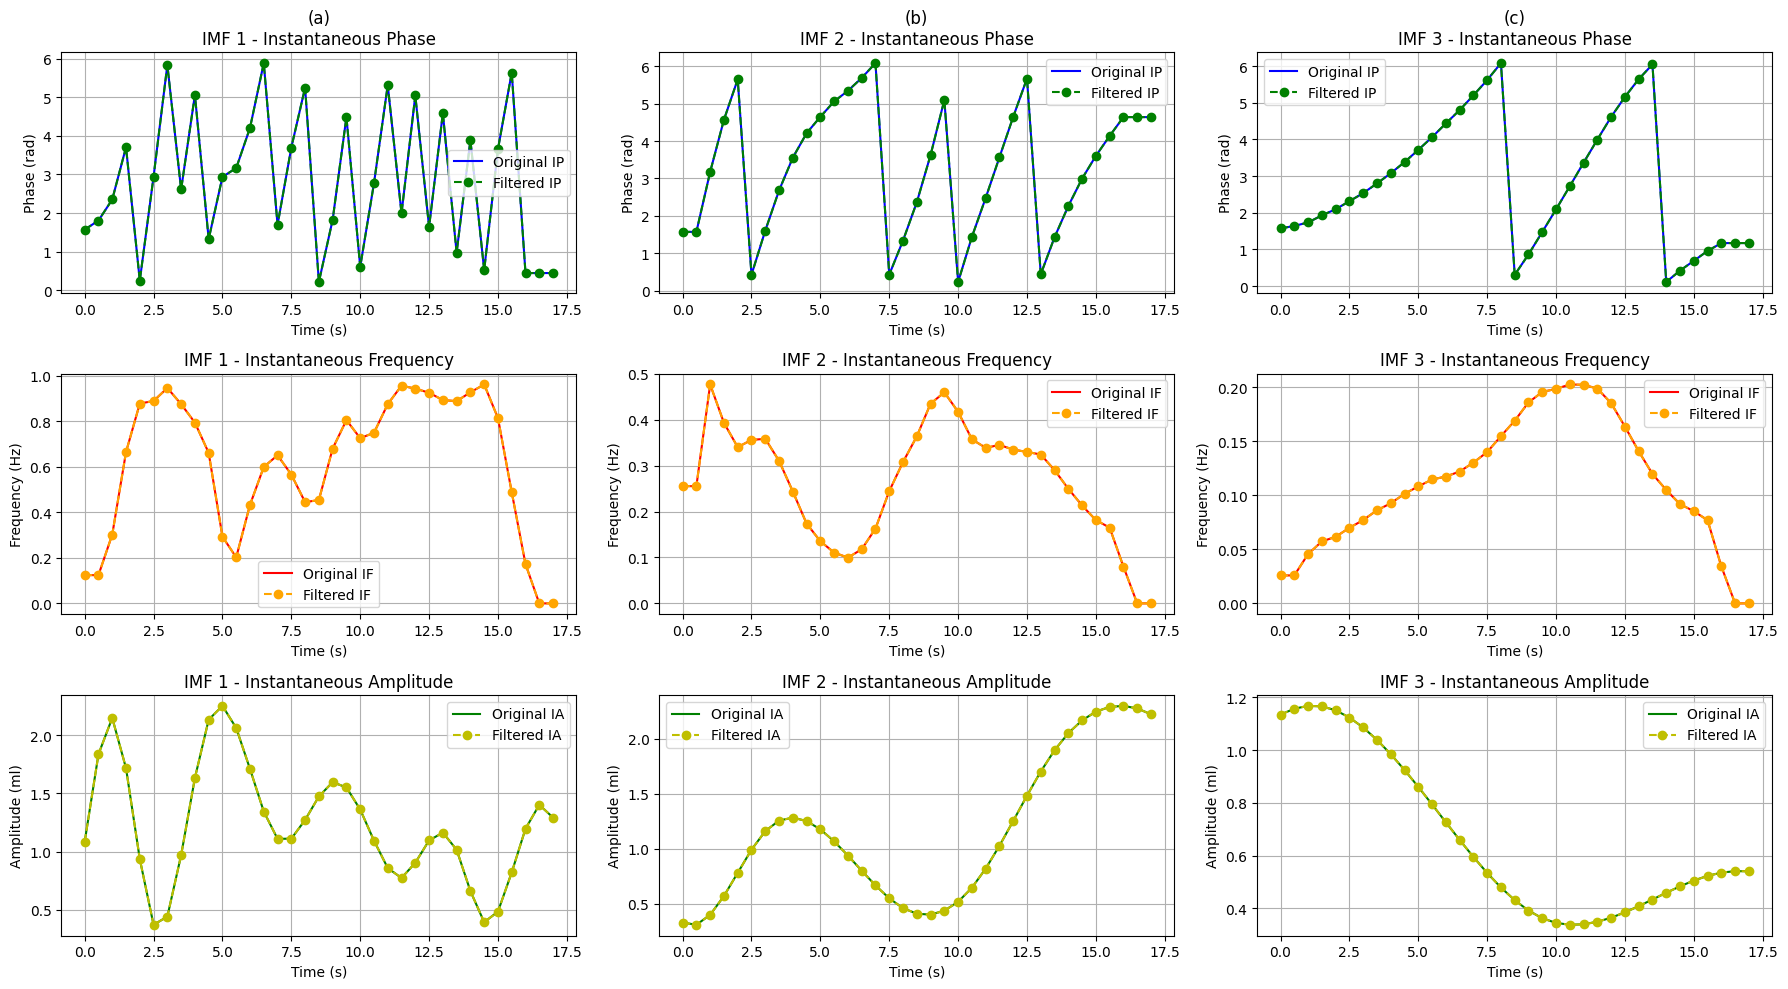

In [ ]:
import string

# Generate subplot labels: (a), (b), (c), ...
labels = [f"({c})" for c in string.ascii_lowercase]

num_to_plot = min(3, len(IPs))  # Số IMF để vẽ
time = np.linspace(0, len(IPs[0]) / sample_rate, len(IPs[0]), endpoint=False)

fig, axes = plt.subplots(3, num_to_plot, figsize=(6 * num_to_plot, 10), sharex=False)

for i in range(num_to_plot):
    # IP (Pha)
    label_index = i  # offset because (a) was used for original signal
    axes[0, i].plot(time, orig_IPs[i], color='b', label='Original IP')
    axes[0, i].plot(time, IPs[i], color='green', linestyle='--', marker='o', label='Filtered IP')
    axes[0, i].set_title(f"{labels[label_index]}""\n"f"IMF {i+1} - Instantaneous Phase")
    axes[0, i].set_ylabel("Phase (rad)")
    axes[0, i].set_xlabel("Time (s)")
    axes[0, i].grid(True)
    axes[0, i].legend()

    # IF (Tần số)
    axes[1, i].plot(time, orig_IFs[i], color='red', label='Original IF')
    axes[1, i].plot(time, IFs[i], color='orange', linestyle='--', marker='o', label='Filtered IF')
    axes[1, i].set_title(f"IMF {i+1} - Instantaneous Frequency")
    axes[1, i].set_ylabel("Frequency (Hz)")
    axes[1, i].set_xlabel("Time (s)")
    axes[1, i].grid(True)
    axes[1, i].legend()

    # IA (Biên độ)
    axes[2, i].plot(time, orig_IAs[i], color='g', label='Original IA')
    axes[2, i].plot(time, IAs[i], color='y', linestyle='--', marker='o', label='Filtered IA')
    axes[2, i].set_title(f"IMF {i+1} - Instantaneous Amplitude")
    axes[2, i].set_ylabel("Amplitude (ml)")
    axes[2, i].set_xlabel("Time (s)")
    axes[2, i].grid(True)
    axes[2, i].legend()

plt.tight_layout()
plt.savefig("compare_original_vs_filtered_IMFs.pdf", format="pdf", bbox_inches="tight")
plt.show()


C:\Users\resea\AppData\Local\Temp\ipykernel_93384\3096650064.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


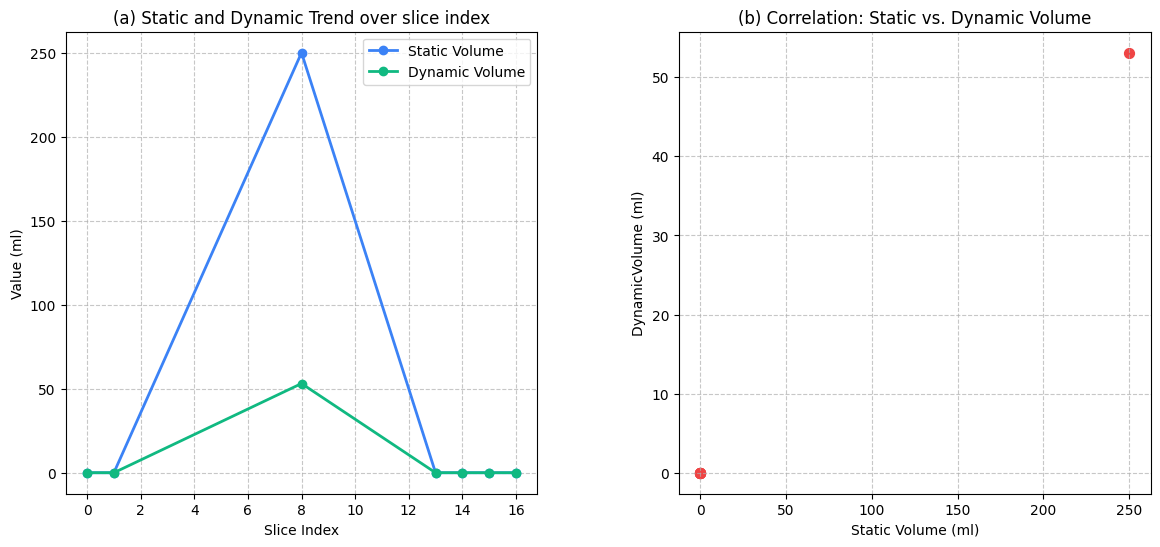

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV data
data = pd.read_csv('slice_static_amplitude_summary.csv')

# Clean the data by filtering out invalid rows
data = data.dropna()
data = data[data['Slice Index'].notnull() & data['Static (IMF_last Mean)'].notnull() & data['Amplitude Sum'].notnull()]

# Convert columns to appropriate types
data['Slice Index'] = data['Slice Index'].astype(int)
data['Static (IMF_last Mean)'] = data['Static (IMF_last Mean)'].astype(float)
data['Amplitude Sum'] = data['Amplitude Sum'].astype(float)

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'wspace': 0.3})

# Line plot for trends over Slice Index
ax1.plot(data['Slice Index'], data['Static (IMF_last Mean)'], marker='o', label='Static Volume', color='#3B82F6', linewidth=2)
ax1.plot(data['Slice Index'], data['Amplitude Sum'], marker='o', label='Dynamic Volume', color='#10B981', linewidth=2)
ax1.set_xlabel('Slice Index')
ax1.set_ylabel('Value (ml)')
ax1.set_title('(a) Static and Dynamic Trend over slice index')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Scatter plot for correlation
ax2.scatter(data['Static (IMF_last Mean)'], data['Amplitude Sum'], color='#EF4444', s=50)
ax2.set_xlabel('Static Volume (ml)')
ax2.set_ylabel('DynamicVolume (ml)')
ax2.set_title('(b) Correlation: Static vs. Dynamic Volume')
ax2.grid(True, linestyle='--', alpha=0.7)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.savefig("Trend over slice.pdf", format="pdf", bbox_inches="tight")
# Display the plots

plt.show()

## Further Reading & References



Andrew J. Quinn, Vítor Lopes-dos-Santos, Norden Huang, Wei-Kuang Liang, Chi-Hung Juan, Jia-Rong Yeh, Anna C. Nobre, David Dupret, and Mark W. Woolrich (2001)
Within-cycle instantaneous frequency profiles report oscillatory waveform dynamics
Journal of Neurophysiology 126:4, 1190-1208
https://doi.org/10.1152/jn.00201.2021

